# 03 — System Studies: Multimodal, Power, Hardware, IR (v8–v12)
*multimodal_v10 imports multimodal_v8; e4 imports nodal_ir_v12 + tts_chip_sim_v7
(from bundle 02). Runtimes: mm ~20s each, trimodal ~1 min, power instant,
nodal E1-E3 ~3.5 min, E4 ~2 min.*

**Contents:** multimodal interference grids (v8 enc-only, v10 enc×core + power
+ modality scaling), trimodal sum-bus fusion with novel-function test (v11),
power study from real charge flow (v9), physical layout renderer (v8),
exact nodal IR solver + compensation + rail droop + head-cal rescue (v12).
Key findings: F13, F14, F15, F6-ext.

In [ ]:
%%writefile multimodal_v8.py
"""
multimodal_v8.py — multiple fixed encoders, one shared memristor core.

Two input formats, one task (recognize the digit 0-9):
  IMG encoder: 8x8 pixels (64 lines, 16-slot PWM)      -> latent 32
  TXT encoder: typed digit word, one-hot 27x5 = 135    -> latent 32
Shared latent bus (32 lines) -> CORE 32x24 (programmable memristor)
-> DECODER 24x10.

Experimental axes:
  enc_frac  in {0.0, 0.5, 1.0}   baked fraction of each encoder (column-wise)
  dec_frac  in {0.0, 1.0}        decoder baked or programmable
  core: always programmable (the shared adaptive element)

Deployment shifts: IMG = 1px translate + sensor noise; TXT = 15% typos.
Adaptation protocol per config (200 samples each, programmable parts only):
  step 1: adapt on shifted IMG  -> measure IMG recovery AND TXT collateral
  step 2: then adapt on shifted TXT -> both again (interference/forgetting)
"""
import numpy as np, csv, time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

SIGMA_FAB, SIGMA_PROG, N_LEVELS = 0.05, 0.04, 16
N_SEEDS = 5
relu = lambda x: np.maximum(0, x)
def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True)); return e / e.sum(axis=1, keepdims=True)

ALPHA = "abcdefghijklmnopqrstuvwxyz "
WORDS = ["zero","one","two","three","four","five","six","seven","eight","nine"]
L = 5

def enc_word(w):
    v = np.zeros((L, 27))
    for p, ch in enumerate(w[:L].ljust(L)):
        v[p, ALPHA.index(ch)] = 1
    return v.ravel()

def txt_batch(n, rng, typo=0.0):
    X = np.zeros((n, L * 27)); y = rng.integers(0, 10, n)
    for i in range(n):
        w = list(WORDS[y[i]])
        for p in range(len(w)):
            if rng.random() < typo:
                w[p] = ALPHA[rng.integers(26)]
        X[i] = enc_word("".join(w))
    return X, y

def img_shift(X, rng):
    im = X.reshape(-1, 8, 8); im = np.roll(im, 1, 2); im[:, :, 0] = 0
    return np.clip(im + rng.normal(0, 0.10, im.shape), 0, 1).reshape(len(X), -1)

class MM:
    """Two encoders -> shared core -> decoder."""
    def __init__(s, rng, H=32, C=24):
        s.We_i = rng.normal(0, np.sqrt(2 / 64), (64, H))
        s.We_t = rng.normal(0, np.sqrt(2 / 135), (135, H))
        s.be_i = np.zeros(H); s.be_t = np.zeros(H)
        s.Wc = rng.normal(0, np.sqrt(2 / H), (H, C)); s.bc = np.zeros(C)
        s.Wd = rng.normal(0, np.sqrt(2 / C), (C, 10)); s.bd = np.zeros(10)
    def fwd(s, X, mode):
        We, be = (s.We_i, s.be_i) if mode == "img" else (s.We_t, s.be_t)
        h = relu(X @ We + be)
        c = relu(h @ s.Wc + s.bc)
        return h, c, c @ s.Wd + s.bd
    def train_step(s, X, y, mode, lr, masks):
        h, c, o = s.fwd(X, mode)
        p = softmax(o); d = (p - np.eye(10)[y]) / len(X)
        gWd = c.T @ d; gbd = d.sum(0)
        dc = (d @ s.Wd.T) * (c > 0)
        gWc = h.T @ dc; gbc = dc.sum(0)
        dh = (dc @ s.Wc.T) * (h > 0)
        We = s.We_i if mode == "img" else s.We_t
        gWe = X.T @ dh; gbe = dh.sum(0)
        me, mc, md = masks
        s.Wd -= lr * gWd * md[None, :]; s.bd -= lr * gbd * md
        s.Wc -= lr * gWc * mc[None, :]; s.bc -= lr * gbc * mc
        if mode == "img":
            s.We_i -= lr * gWe * me[None, :]; s.be_i -= lr * gbe * me
        else:
            s.We_t -= lr * gWe * me[None, :]; s.be_t -= lr * gbe * me
    def acc(s, X, y, mode): return (s.fwd(X, mode)[2].argmax(1) == y).mean()

def dev_noise(W, cols_baked, rng):
    W = W.copy()
    if cols_baked.any():
        W[:, cols_baked] *= (1 + rng.normal(0, SIGMA_FAB, W[:, cols_baked].shape))
    pc = ~cols_baked
    if pc.any():
        sub = W[:, pc]; sc = np.abs(sub).max() + 1e-12
        st = 1.0 / (N_LEVELS - 1)
        q = lambda G: np.clip(np.round(G / st) * st + rng.normal(0, SIGMA_PROG, G.shape), 0, 1)
        W[:, pc] = (q(np.clip(sub, 0, None) / sc) - q(np.clip(-sub, 0, None) / sc)) * sc
    return W

if __name__ == "__main__":
    t0 = time.time()
    X, y = load_digits(return_X_y=True)
    Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X / 16.0, y, test_size=0.35,
                                                  random_state=42, stratify=y)
    rows = []
    for seed in range(N_SEEDS):
        rng = np.random.default_rng(seed)
        Xt_tr, yt_tr = txt_batch(3000, np.random.default_rng(50 + seed), typo=0.03)
        Xt_te, yt_te = txt_batch(1000, np.random.default_rng(150 + seed), typo=0.03)
        # joint training (float, ex-situ)
        m = MM(rng)
        ones = (np.ones(32, bool), np.ones(24, bool), np.ones(10, bool))
        for ep in range(220):
            idx = rng.permutation(len(Xi_tr))
            for st in range(0, len(idx), 32):
                bi = idx[st:st + 32]
                m.train_step(Xi_tr[bi], yi_tr[bi], "img", 0.05, ones)
                bt = rng.integers(0, len(Xt_tr), 32)
                m.train_step(Xt_tr[bt], yt_tr[bt], "txt", 0.05, ones)
        # shifted test sets + adaptation sets
        Xi_s = img_shift(Xi_te, np.random.default_rng(1000 + seed))
        Xi_ad = img_shift(Xi_tr, np.random.default_rng(1000 + seed))
        ad = rng.choice(len(Xi_ad), 200, replace=False)
        Xi_ad, yi_ad = Xi_ad[ad], yi_tr[ad]
        Xt_s, yt_s = txt_batch(1000, np.random.default_rng(2000 + seed), typo=0.15)
        Xt_ad, yt_ad = txt_batch(200, np.random.default_rng(3000 + seed), typo=0.15)

        for enc_f in [0.0, 0.5, 1.0]:
            for dec_f in [0.0, 1.0]:
                r2 = np.random.default_rng(9000 + seed)
                d = MM(np.random.default_rng(0))
                ecols = np.arange(32) < int(round(enc_f * 32))
                dcols = np.arange(10) < int(round(dec_f * 10))
                ccols = np.zeros(24, bool)              # core all programmable
                d.We_i = dev_noise(m.We_i, ecols, r2); d.We_t = dev_noise(m.We_t, ecols, r2)
                d.Wc = dev_noise(m.Wc, ccols, r2); d.Wd = dev_noise(m.Wd, dcols, r2)
                d.be_i, d.be_t = m.be_i.copy(), m.be_t.copy()
                d.bc, d.bd = m.bc.copy(), m.bd.copy()
                masks = (~ecols, ~ccols, ~dcols)
                def snap(stage):
                    rows.append(dict(seed=seed, enc_frac=enc_f, dec_frac=dec_f,
                        stage=stage,
                        img_clean=round(d.acc(Xi_te, yi_te, "img"), 4),
                        txt_clean=round(d.acc(Xt_te, yt_te, "txt"), 4),
                        img_shift=round(d.acc(Xi_s, yi_te, "img"), 4),
                        txt_shift=round(d.acc(Xt_s, yt_s, "txt"), 4)))
                snap("deploy")
                rf = np.random.default_rng(7000 + seed)
                for ep in range(120):
                    bi = rf.permutation(200)
                    for st in range(0, 200, 32):
                        d.train_step(Xi_ad[bi[st:st+32]], yi_ad[bi[st:st+32]],
                                     "img", 0.05, masks)
                d.Wc = dev_noise(d.Wc, ccols, r2)       # re-program write noise
                if (~dcols).any(): d.Wd = dev_noise(d.Wd, dcols, r2)
                if (~ecols).any():
                    d.We_i = dev_noise(d.We_i, ecols, r2)
                snap("after_img_ft")
                for ep in range(120):
                    bi = rf.permutation(200)
                    for st in range(0, 200, 32):
                        d.train_step(Xt_ad[bi[st:st+32]], yt_ad[bi[st:st+32]],
                                     "txt", 0.05, masks)
                d.Wc = dev_noise(d.Wc, ccols, r2)
                if (~dcols).any(): d.Wd = dev_noise(d.Wd, dcols, r2)
                if (~ecols).any():
                    d.We_t = dev_noise(d.We_t, ecols, r2)
                snap("after_txt_ft")
        print(f"seed {seed} {time.time()-t0:.0f}s", flush=True)
    with open("results_v8_multimodal.csv", "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print("saved", len(rows), f"{time.time()-t0:.0f}s")


In [ ]:
%%writefile results_v8_multimodal.csv
seed,enc_frac,dec_frac,stage,img_clean,txt_clean,img_shift,txt_shift
0,0.0,0.0,deploy,0.9396,0.999,0.3943,0.993
0,0.0,0.0,after_img_ft,0.6264,0.999,0.7727,0.986
0,0.0,0.0,after_txt_ft,0.6471,1.0,0.7838,0.993
0,0.0,1.0,deploy,0.9428,0.999,0.3911,0.991
0,0.0,1.0,after_img_ft,0.6598,0.999,0.8362,0.988
0,0.0,1.0,after_txt_ft,0.6693,0.999,0.7933,0.99
0,0.5,0.0,deploy,0.9237,1.0,0.3545,0.986
0,0.5,0.0,after_img_ft,0.5723,0.888,0.787,0.84
0,0.5,0.0,after_txt_ft,0.628,0.998,0.7329,0.984
0,0.5,1.0,deploy,0.9332,1.0,0.3672,0.99
0,0.5,1.0,after_img_ft,0.6105,0.988,0.7727,0.95
0,0.5,1.0,after_txt_ft,0.7011,1.0,0.7838,0.988
0,1.0,0.0,deploy,0.9444,1.0,0.3975,0.988
0,1.0,0.0,after_img_ft,0.5564,0.897,0.7345,0.869
0,1.0,0.0,after_txt_ft,0.5898,0.997,0.6184,0.976
0,1.0,1.0,deploy,0.9444,1.0,0.4102,0.988
0,1.0,1.0,after_img_ft,0.5056,0.987,0.7886,0.929
0,1.0,1.0,after_txt_ft,0.5437,0.999,0.6439,0.982
1,0.0,0.0,deploy,0.9412,1.0,0.3975,0.984
1,0.0,0.0,after_img_ft,0.6693,0.997,0.8378,0.958
1,0.0,0.0,after_txt_ft,0.655,1.0,0.7727,0.98
1,0.0,1.0,deploy,0.9555,1.0,0.4102,0.984
1,0.0,1.0,after_img_ft,0.6391,0.998,0.8315,0.975
1,0.0,1.0,after_txt_ft,0.6518,1.0,0.841,0.988
1,0.5,0.0,deploy,0.8712,1.0,0.3688,0.987
1,0.5,0.0,after_img_ft,0.5787,0.993,0.7886,0.941
1,0.5,0.0,after_txt_ft,0.6804,0.999,0.7154,0.988
1,0.5,1.0,deploy,0.9269,1.0,0.3704,0.988
1,0.5,1.0,after_img_ft,0.5199,0.998,0.8108,0.963
1,0.5,1.0,after_txt_ft,0.531,1.0,0.7663,0.978
1,1.0,0.0,deploy,0.9205,1.0,0.3879,0.983
1,1.0,0.0,after_img_ft,0.5342,0.767,0.7711,0.785
1,1.0,0.0,after_txt_ft,0.6232,1.0,0.6423,0.98
1,1.0,1.0,deploy,0.9491,1.0,0.4006,0.982
1,1.0,1.0,after_img_ft,0.5564,0.868,0.7583,0.849
1,1.0,1.0,after_txt_ft,0.6057,1.0,0.6932,0.984
2,0.0,0.0,deploy,0.8951,0.997,0.3418,0.981
2,0.0,0.0,after_img_ft,0.5771,0.991,0.8553,0.957
2,0.0,0.0,after_txt_ft,0.566,0.998,0.7917,0.97
2,0.0,1.0,deploy,0.9285,0.997,0.3514,0.98
2,0.0,1.0,after_img_ft,0.744,0.995,0.8728,0.977
2,0.0,1.0,after_txt_ft,0.752,0.998,0.8076,0.981
2,0.5,0.0,deploy,0.9285,0.998,0.4165,0.98
2,0.5,0.0,after_img_ft,0.7234,0.98,0.8045,0.891
2,0.5,0.0,after_txt_ft,0.8203,0.998,0.6884,0.97
2,0.5,1.0,deploy,0.9285,0.997,0.4229,0.981
2,0.5,1.0,after_img_ft,0.6963,0.991,0.849,0.961
2,0.5,1.0,after_txt_ft,0.8029,0.998,0.8251,0.978
2,1.0,0.0,deploy,0.9539,0.998,0.4308,0.976
2,1.0,0.0,after_img_ft,0.6105,0.68,0.7933,0.615
2,1.0,0.0,after_txt_ft,0.7854,0.998,0.5024,0.978
2,1.0,1.0,deploy,0.9475,0.998,0.4388,0.978
2,1.0,1.0,after_img_ft,0.6296,0.798,0.7965,0.731
2,1.0,1.0,after_txt_ft,0.7488,0.997,0.5421,0.968
3,0.0,0.0,deploy,0.9348,0.997,0.4197,0.978
3,0.0,0.0,after_img_ft,0.5787,0.992,0.8712,0.965
3,0.0,0.0,after_txt_ft,0.6709,0.997,0.8076,0.979
3,0.0,1.0,deploy,0.9571,0.998,0.4054,0.979
3,0.0,1.0,after_img_ft,0.6153,0.997,0.8887,0.973
3,0.0,1.0,after_txt_ft,0.5596,0.997,0.8442,0.976
3,0.5,0.0,deploy,0.9491,0.997,0.4054,0.98
3,0.5,0.0,after_img_ft,0.4626,0.983,0.8362,0.907
3,0.5,0.0,after_txt_ft,0.6979,0.996,0.7329,0.979
3,0.5,1.0,deploy,0.9491,0.997,0.4229,0.981
3,0.5,1.0,after_img_ft,0.6073,0.988,0.8728,0.94
3,0.5,1.0,after_txt_ft,0.7329,0.997,0.8521,0.98
3,1.0,0.0,deploy,0.9348,0.998,0.3847,0.978
3,1.0,0.0,after_img_ft,0.5437,0.881,0.8172,0.821
3,1.0,0.0,after_txt_ft,0.7424,0.996,0.5692,0.976
3,1.0,1.0,deploy,0.9539,0.998,0.4006,0.983
3,1.0,1.0,after_img_ft,0.5056,0.893,0.8378,0.856
3,1.0,1.0,after_txt_ft,0.5358,0.991,0.6725,0.962
4,0.0,0.0,deploy,0.9507,0.999,0.4102,0.984
4,0.0,0.0,after_img_ft,0.7933,1.0,0.8188,0.978
4,0.0,0.0,after_txt_ft,0.7154,0.999,0.7901,0.987
4,0.0,1.0,deploy,0.9444,0.999,0.4324,0.982
4,0.0,1.0,after_img_ft,0.7186,0.999,0.8394,0.978
4,0.0,1.0,after_txt_ft,0.7424,0.999,0.8203,0.987
4,0.5,0.0,deploy,0.9523,0.999,0.4388,0.987
4,0.5,0.0,after_img_ft,0.7536,0.999,0.7901,0.955
4,0.5,0.0,after_txt_ft,0.7504,1.0,0.7234,0.977
4,0.5,1.0,deploy,0.9666,0.999,0.442,0.986
4,0.5,1.0,after_img_ft,0.6105,1.0,0.8331,0.983
4,0.5,1.0,after_txt_ft,0.628,1.0,0.8188,0.986
4,1.0,0.0,deploy,0.9348,1.0,0.4181,0.984
4,1.0,0.0,after_img_ft,0.5199,0.803,0.7138,0.794
4,1.0,0.0,after_txt_ft,0.4992,0.998,0.4372,0.969
4,1.0,1.0,deploy,0.9571,1.0,0.3863,0.984
4,1.0,1.0,after_img_ft,0.5866,0.895,0.7933,0.866
4,1.0,1.0,after_txt_ft,0.7091,0.999,0.628,0.984


In [ ]:
%%writefile multimodal_v10.py
"""
multimodal_v10.py — the full enc x core baking grid, plus power.
Grid: enc_frac x core_frac in {0,0.5,1}^2, decoder programmable.
Protocol: deploy -> IMG fine-tune -> TXT fine-tune.
Power model per config: baked printed R (1uS, no off-leak) vs memristor
(25uS, on/off 30 -> leak whenever stage sees voltage). Encoders gated by
modality (quiescent = no leak); shared core+decoder powered every frame.
Windows enc/core/dec = 32/32/64 us, V=1V, frame 10ms; 66 periphery
channels 7uA@3.3V duty-cycled; sequencer 10uW; drivers 2.4uW.
"""
import numpy as np, csv, time
from multimodal_v8 import MM, dev_noise, txt_batch, img_shift
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

N_SEEDS = 5
VREAD, VLOGIC = 1.0, 3.3
G_BAKED, G_MEM, ONOFF = 1e-6, 25e-6, 30.0
T_ENC, T_CORE, T_DEC = 32e-6, 32e-6, 64e-6
FRAME = 0.01
I_CH = 7e-6
P_SEQ, P_DRV = 10e-6, 2.4e-6

def stage_power(Wm, frac_baked_cols, duty_in, T, active_share=1.0):
    n_cols = Wm.shape[1]; nb = int(round(frac_baked_cols * n_cols))
    cb = np.arange(n_cols) < nb
    wmax = np.abs(Wm).max() + 1e-12
    g_b = np.abs(Wm[:, cb]).sum() / wmax * G_BAKED
    g_p = np.abs(Wm[:, ~cb]).sum() / wmax * G_MEM
    g_leak = Wm[:, ~cb].size * G_MEM / ONOFF
    E = VREAD**2 * ((g_b + g_p) * duty_in + g_leak) * T
    return E / FRAME * active_share

def config_power(m, enc_f, core_f, duties, n_modalities=2):
    d_enc, d_core, d_dec = duties
    share = 1.0 / n_modalities
    p = stage_power(m.We_i, enc_f, d_enc, T_ENC, share)
    p += stage_power(m.We_t, enc_f, d_enc, T_ENC, share) * (n_modalities - 1)
    p += stage_power(m.Wc, core_f, d_core, T_CORE, 1.0)
    p += stage_power(m.Wd, 0.0, d_dec, T_DEC, 1.0)
    p += 66 * I_CH * VLOGIC * (T_ENC + T_CORE + T_DEC) / FRAME / 3
    p += P_SEQ + P_DRV
    return p

if __name__ == "__main__":
    t0 = time.time()
    X, y = load_digits(return_X_y=True)
    Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X / 16.0, y, test_size=0.35,
                                                  random_state=42, stratify=y)
    rows = []
    for seed in range(N_SEEDS):
        rng = np.random.default_rng(seed)
        Xt_tr, yt_tr = txt_batch(3000, np.random.default_rng(50 + seed), typo=0.03)
        Xt_te, yt_te = txt_batch(1000, np.random.default_rng(150 + seed), typo=0.03)
        m = MM(rng)
        ones = (np.ones(32, bool), np.ones(24, bool), np.ones(10, bool))
        for ep in range(220):
            idx = rng.permutation(len(Xi_tr))
            for st in range(0, len(idx), 32):
                bi = idx[st:st + 32]
                m.train_step(Xi_tr[bi], yi_tr[bi], "img", 0.05, ones)
                bt = rng.integers(0, len(Xt_tr), 32)
                m.train_step(Xt_tr[bt], yt_tr[bt], "txt", 0.05, ones)
        hi, ci, _ = m.fwd(Xi_te, "img"); ht, ct, _ = m.fwd(Xt_te, "txt")
        c1 = np.percentile(np.vstack([hi, ht]), 99.5)
        c2 = np.percentile(np.vstack([ci, ct]), 99.5)
        duties = (0.06,
                  float(np.clip(np.vstack([hi, ht]) / c1, 0, 1).mean()),
                  float(np.clip(np.vstack([ci, ct]) / c2, 0, 1).mean()))
        Xi_s = img_shift(Xi_te, np.random.default_rng(1000 + seed))
        Xi_ad = img_shift(Xi_tr, np.random.default_rng(1000 + seed))
        ad = rng.choice(len(Xi_ad), 200, replace=False)
        Xi_ad, yi_ad = Xi_ad[ad], yi_tr[ad]
        Xt_s, yt_s = txt_batch(1000, np.random.default_rng(2000 + seed), typo=0.15)
        Xt_ad, yt_ad = txt_batch(200, np.random.default_rng(3000 + seed), typo=0.15)
        for enc_f in [0.0, 0.5, 1.0]:
            for core_f in [0.0, 0.5, 1.0]:
                r2 = np.random.default_rng(9000 + seed)
                d = MM(np.random.default_rng(0))
                ecols = np.arange(32) < int(round(enc_f * 32))
                ccols = np.arange(24) < int(round(core_f * 24))
                dcols = np.zeros(10, bool)
                d.We_i = dev_noise(m.We_i, ecols, r2); d.We_t = dev_noise(m.We_t, ecols, r2)
                d.Wc = dev_noise(m.Wc, ccols, r2); d.Wd = dev_noise(m.Wd, dcols, r2)
                d.be_i, d.be_t = m.be_i.copy(), m.be_t.copy()
                d.bc, d.bd = m.bc.copy(), m.bd.copy()
                masks = (~ecols, ~ccols, ~dcols)
                pw = config_power(m, enc_f, core_f, duties)
                def snap(stage):
                    rows.append(dict(seed=seed, enc_frac=enc_f, core_frac=core_f,
                        stage=stage, power_uW=round(pw * 1e6, 2),
                        img_shift=round(d.acc(Xi_s, yi_te, "img"), 4),
                        txt_shift=round(d.acc(Xt_s, yt_s, "txt"), 4),
                        img_clean=round(d.acc(Xi_te, yi_te, "img"), 4),
                        txt_clean=round(d.acc(Xt_te, yt_te, "txt"), 4)))
                snap("deploy")
                rf = np.random.default_rng(7000 + seed)
                for ep in range(120):
                    bi = rf.permutation(200)
                    for st in range(0, 200, 32):
                        d.train_step(Xi_ad[bi[st:st+32]], yi_ad[bi[st:st+32]],
                                     "img", 0.05, masks)
                d.Wd = dev_noise(d.Wd, dcols, r2)
                if (~ccols).any(): d.Wc = dev_noise(d.Wc, ccols, r2)
                if (~ecols).any(): d.We_i = dev_noise(d.We_i, ecols, r2)
                snap("after_img_ft")
                for ep in range(120):
                    bi = rf.permutation(200)
                    for st in range(0, 200, 32):
                        d.train_step(Xt_ad[bi[st:st+32]], yt_ad[bi[st:st+32]],
                                     "txt", 0.05, masks)
                d.Wd = dev_noise(d.Wd, dcols, r2)
                if (~ccols).any(): d.Wc = dev_noise(d.Wc, ccols, r2)
                if (~ecols).any(): d.We_t = dev_noise(d.We_t, ecols, r2)
                snap("after_txt_ft")
        print(f"seed {seed} {time.time()-t0:.0f}s", flush=True)
    with open("results_v10_multimodal.csv", "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    m0 = MM(np.random.default_rng(0)); duties0 = (0.06, 0.30, 0.30)
    scal = []
    for M in [1, 2, 3, 4, 6, 8]:
        for core_f, tag in [(0.0, "prog_core"), (1.0, "baked_core")]:
            p_sh = config_power(m0, 1.0, core_f, duties0, n_modalities=M)
            p_1 = config_power(m0, 1.0, core_f, duties0, n_modalities=1)
            scal.append(dict(M=M, core=tag, shared_uW=round(p_sh * 1e6, 2),
                             separate_uW=round(p_1 * 1e6 * M, 2)))
    with open("results_v10_mscaling.csv", "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(scal[0].keys()))
        w.writeheader(); w.writerows(scal)
    print("saved", len(rows), "rows +", len(scal))


In [ ]:
%%writefile results_v10_multimodal.csv
seed,enc_frac,core_frac,stage,power_uW,img_shift,txt_shift,img_clean,txt_clean
0,0.0,0.0,deploy,36.43,0.3943,0.993,0.9396,0.999
0,0.0,0.0,after_img_ft,36.43,0.7695,0.975,0.6645,0.999
0,0.0,0.0,after_txt_ft,36.43,0.779,0.986,0.6216,0.998
0,0.0,0.5,deploy,34.59,0.3641,0.98,0.9237,1.0
0,0.0,0.5,after_img_ft,34.59,0.7854,0.983,0.7091,1.0
0,0.0,0.5,after_txt_ft,34.59,0.779,0.985,0.6995,0.999
0,0.0,1.0,deploy,32.74,0.3704,0.991,0.9507,1.0
0,0.0,1.0,after_img_ft,32.74,0.8299,0.986,0.6534,1.0
0,0.0,1.0,after_txt_ft,32.74,0.8219,0.99,0.6948,1.0
0,0.5,0.0,deploy,31.04,0.3545,0.986,0.9237,1.0
0,0.5,0.0,after_img_ft,31.04,0.7854,0.866,0.6137,0.893
0,0.5,0.0,after_txt_ft,31.04,0.5787,0.987,0.4626,1.0
0,0.5,0.5,deploy,29.2,0.4181,0.989,0.9571,0.999
0,0.5,0.5,after_img_ft,29.2,0.7583,0.953,0.6216,0.993
0,0.5,0.5,after_txt_ft,29.2,0.6963,0.983,0.6439,0.998
0,0.5,1.0,deploy,27.35,0.4118,0.989,0.9444,1.0
0,0.5,1.0,after_img_ft,27.35,0.7599,0.855,0.6486,0.889
0,0.5,1.0,after_txt_ft,27.35,0.7281,0.99,0.6932,1.0
0,1.0,0.0,deploy,25.69,0.3975,0.988,0.9444,1.0
0,1.0,0.0,after_img_ft,25.69,0.7393,0.924,0.5692,0.984
0,1.0,0.0,after_txt_ft,25.69,0.6232,0.981,0.6391,0.997
0,1.0,0.5,deploy,23.85,0.4134,0.993,0.9444,1.0
0,1.0,0.5,after_img_ft,23.85,0.7154,0.845,0.6439,0.875
0,1.0,0.5,after_txt_ft,23.85,0.4785,0.978,0.717,0.999
0,1.0,1.0,deploy,22.0,0.4308,0.99,0.9539,1.0
0,1.0,1.0,after_img_ft,22.0,0.7011,0.719,0.5707,0.775
0,1.0,1.0,after_txt_ft,22.0,0.4944,0.979,0.7695,0.997
1,0.0,0.0,deploy,36.38,0.3975,0.984,0.9412,1.0
1,0.0,0.0,after_img_ft,36.38,0.7599,0.956,0.5851,0.998
1,0.0,0.0,after_txt_ft,36.38,0.7965,0.982,0.6375,1.0
1,0.0,0.5,deploy,34.58,0.3847,0.984,0.9078,1.0
1,0.0,0.5,after_img_ft,34.58,0.7965,0.96,0.5866,0.998
1,0.0,0.5,after_txt_ft,34.58,0.8362,0.983,0.6471,1.0
1,0.0,1.0,deploy,32.84,0.4197,0.988,0.9412,1.0
1,0.0,1.0,after_img_ft,32.84,0.849,0.981,0.7059,1.0
1,0.0,1.0,after_txt_ft,32.84,0.8124,0.979,0.7234,1.0
1,0.5,0.0,deploy,31.05,0.3688,0.987,0.8712,1.0
1,0.5,0.0,after_img_ft,31.05,0.7599,0.944,0.5898,0.993
1,0.5,0.0,after_txt_ft,31.05,0.6948,0.982,0.6852,1.0
1,0.5,0.5,deploy,29.25,0.399,0.98,0.9475,1.0
1,0.5,0.5,after_img_ft,29.25,0.8029,0.849,0.5596,0.872
1,0.5,0.5,after_txt_ft,29.25,0.744,0.981,0.6486,1.0
1,0.5,1.0,deploy,27.51,0.4086,0.984,0.9396,1.0
1,0.5,1.0,after_img_ft,27.51,0.8045,0.973,0.6169,0.999
1,0.5,1.0,after_txt_ft,27.51,0.7631,0.984,0.6121,1.0
1,1.0,0.0,deploy,25.65,0.3879,0.983,0.9205,1.0
1,1.0,0.0,after_img_ft,25.65,0.7456,0.817,0.5199,0.862
1,1.0,0.0,after_txt_ft,25.65,0.6598,0.983,0.6757,1.0
1,1.0,0.5,deploy,23.85,0.4118,0.984,0.9412,1.0
1,1.0,0.5,after_img_ft,23.85,0.7313,0.822,0.5262,0.899
1,1.0,0.5,after_txt_ft,23.85,0.504,0.978,0.717,1.0
1,1.0,1.0,deploy,22.11,0.4531,0.988,0.965,1.0
1,1.0,1.0,after_img_ft,22.11,0.6884,0.857,0.539,0.872
1,1.0,1.0,after_txt_ft,22.11,0.3259,0.974,0.4992,0.998
2,0.0,0.0,deploy,36.86,0.3418,0.981,0.8951,0.997
2,0.0,0.0,after_img_ft,36.86,0.8124,0.954,0.5771,0.991
2,0.0,0.0,after_txt_ft,36.86,0.7424,0.942,0.6518,0.99
2,0.0,0.5,deploy,35.08,0.4102,0.981,0.9459,0.997
2,0.0,0.5,after_img_ft,35.08,0.8537,0.97,0.6582,0.993
2,0.0,0.5,after_txt_ft,35.08,0.8124,0.978,0.7297,0.999
2,0.0,1.0,deploy,33.27,0.399,0.981,0.9396,0.997
2,0.0,1.0,after_img_ft,33.27,0.8617,0.977,0.6868,0.996
2,0.0,1.0,after_txt_ft,33.27,0.8156,0.977,0.725,0.999
2,0.5,0.0,deploy,31.47,0.4165,0.98,0.9285,0.998
2,0.5,0.0,after_img_ft,31.47,0.8283,0.92,0.7218,0.984
2,0.5,0.0,after_txt_ft,31.47,0.7552,0.975,0.7949,0.996
2,0.5,0.5,deploy,29.7,0.4245,0.975,0.9475,1.0
2,0.5,0.5,after_img_ft,29.7,0.8267,0.839,0.725,0.894
2,0.5,0.5,after_txt_ft,29.7,0.6709,0.971,0.8299,0.996
2,0.5,1.0,deploy,27.88,0.4308,0.976,0.9539,1.0
2,0.5,1.0,after_img_ft,27.88,0.841,0.822,0.6868,0.893
2,0.5,1.0,after_txt_ft,27.88,0.7679,0.972,0.7822,0.999
2,1.0,0.0,deploy,26.14,0.4308,0.976,0.9539,0.998
2,1.0,0.0,after_img_ft,26.14,0.7774,0.589,0.5914,0.585
2,1.0,0.0,after_txt_ft,26.14,0.4754,0.968,0.7742,0.995
2,1.0,0.5,deploy,24.37,0.3927,0.98,0.9285,0.998
2,1.0,0.5,after_img_ft,24.37,0.8251,0.735,0.6407,0.8
2,1.0,0.5,after_txt_ft,24.37,0.4913,0.97,0.7663,0.996
2,1.0,1.0,deploy,22.56,0.4118,0.979,0.9444,0.998
2,1.0,1.0,after_img_ft,22.56,0.787,0.555,0.5676,0.571
2,1.0,1.0,after_txt_ft,22.56,0.4817,0.973,0.868,0.998
3,0.0,0.0,deploy,37.51,0.4197,0.978,0.9348,0.997
3,0.0,0.0,after_img_ft,37.51,0.8362,0.956,0.6169,0.99
3,0.0,0.0,after_txt_ft,37.51,0.6916,0.979,0.663,0.998
3,0.0,0.5,deploy,35.39,0.4388,0.978,0.9634,0.995
3,0.0,0.5,after_img_ft,35.39,0.8649,0.948,0.4928,0.991
3,0.0,0.5,after_txt_ft,35.39,0.8553,0.976,0.6677,0.995
3,0.0,1.0,deploy,33.36,0.372,0.987,0.9603,0.998
3,0.0,1.0,after_img_ft,33.36,0.8808,0.974,0.6025,0.995
3,0.0,1.0,after_txt_ft,33.36,0.849,0.976,0.6693,0.997
3,0.5,0.0,deploy,32.09,0.4054,0.98,0.9491,0.997
3,0.5,0.0,after_img_ft,32.09,0.8203,0.966,0.6502,0.994
3,0.5,0.0,after_txt_ft,32.09,0.7488,0.964,0.6804,0.991
3,0.5,0.5,deploy,29.97,0.3879,0.983,0.9603,0.998
3,0.5,0.5,after_img_ft,29.97,0.8378,0.958,0.4452,0.993
3,0.5,0.5,after_txt_ft,29.97,0.8315,0.977,0.6328,0.995
3,0.5,1.0,deploy,27.94,0.3847,0.981,0.9539,0.998
3,0.5,1.0,after_img_ft,27.94,0.8569,0.931,0.4372,0.984
3,0.5,1.0,after_txt_ft,27.94,0.8251,0.974,0.5103,0.993
3,1.0,0.0,deploy,26.64,0.3847,0.978,0.9348,0.998
3,1.0,0.0,after_img_ft,26.64,0.8521,0.831,0.5421,0.889
3,1.0,0.0,after_txt_ft,26.64,0.6216,0.968,0.7472,0.991
3,1.0,0.5,deploy,24.52,0.4308,0.98,0.9571,0.996
3,1.0,0.5,after_img_ft,24.52,0.7647,0.744,0.5866,0.789
3,1.0,0.5,after_txt_ft,24.52,0.5946,0.979,0.7679,0.996
3,1.0,1.0,deploy,22.49,0.4197,0.983,0.9587,0.998
3,1.0,1.0,after_img_ft,22.49,0.7822,0.578,0.5358,0.571
3,1.0,1.0,after_txt_ft,22.49,0.4801,0.98,0.8855,0.997
4,0.0,0.0,deploy,36.78,0.4102,0.984,0.9507,0.999
4,0.0,0.0,after_img_ft,36.78,0.841,0.98,0.7345,1.0
4,0.0,0.0,after_txt_ft,36.78,0.7615,0.986,0.725,1.0
4,0.0,0.5,deploy,34.67,0.4181,0.987,0.9475,1.0
4,0.0,0.5,after_img_ft,34.67,0.8458,0.981,0.7266,1.0
4,0.0,0.5,after_txt_ft,34.67,0.8426,0.981,0.7059,1.0
4,0.0,1.0,deploy,32.65,0.4181,0.985,0.9412,0.999
4,0.0,1.0,after_img_ft,32.65,0.8299,0.97,0.6232,1.0
4,0.0,1.0,after_txt_ft,32.65,0.7981,0.982,0.5946,1.0
4,0.5,0.0,deploy,31.42,0.4388,0.987,0.9523,0.999
4,0.5,0.0,after_img_ft,31.42,0.7917,0.952,0.7504,0.995
4,0.5,0.0,after_txt_ft,31.42,0.7965,0.988,0.8045,1.0
4,0.5,0.5,deploy,29.31,0.4404,0.988,0.9587,0.999
4,0.5,0.5,after_img_ft,29.31,0.8124,0.969,0.6932,1.0
4,0.5,0.5,after_txt_ft,29.31,0.7536,0.985,0.6343,1.0
4,0.5,1.0,deploy,27.29,0.442,0.985,0.9618,1.0
4,0.5,1.0,after_img_ft,27.29,0.7806,0.969,0.6566,1.0
4,0.5,1.0,after_txt_ft,27.29,0.7663,0.991,0.6979,1.0
4,1.0,0.0,deploy,26.04,0.4181,0.984,0.9348,1.0
4,1.0,0.0,after_img_ft,26.04,0.7583,0.851,0.5485,0.889
4,1.0,0.0,after_txt_ft,26.04,0.6439,0.976,0.7027,0.999
4,1.0,0.5,deploy,23.93,0.4356,0.991,0.9491,0.999
4,1.0,0.5,after_img_ft,23.93,0.7774,0.776,0.6105,0.797
4,1.0,0.5,after_txt_ft,23.93,0.6264,0.98,0.6773,1.0
4,1.0,1.0,deploy,21.91,0.469,0.986,0.9428,0.999
4,1.0,1.0,after_img_ft,21.91,0.6995,0.692,0.5246,0.7
4,1.0,1.0,after_txt_ft,21.91,0.62,0.981,0.787,0.999


In [ ]:
%%writefile results_v10_mscaling.csv
M,core,shared_uW,separate_uW
1,prog_core,30.35,30.35
1,baked_core,23.99,23.99
2,prog_core,30.41,60.7
2,baked_core,24.05,47.98
3,prog_core,30.43,91.05
3,baked_core,24.07,71.97
4,prog_core,30.44,121.4
4,baked_core,24.08,95.96
6,prog_core,30.45,182.09
6,baked_core,24.09,143.94
8,prog_core,30.45,242.79
8,baked_core,24.09,191.91


In [ ]:
%%writefile trimodal_v11.py
"""
trimodal_v11.py — what does a fully-baked core COST for cross-modal inference?

Three encoders, simultaneous input, analog sum-bus fusion:
  IMG: 8x8 digit image (64 lines)
  TXT: typed digit word, one-hot 27x5 (135 lines)
  AUD: spoken digit word (espeak) -> 16 mel bands x 8 time slices (128 lines)
All encoders drive the SAME 32-line latent bus (currents sum — analog-native
fusion). Core 32->24. TWO output heads:
  head1: fused digit identity (10)
  head2: odd-one-out detection (none/img/aud/txt) — REQUIRES cross-modal
         comparison inside the core.
25% of trials have one modality showing a different digit.
head2's txt-odd class is NEVER seen in training (reserved for T3).

Configs (encoders + decoders programmable in all; the CORE is the variable):
  A: core programmable (memristor)
  B: core fully baked
  C: core baked + parallel memristor adapter rank 4 on the bus->core path
     ("memristor one layer away", F3 hardware-LoRA pattern)

Tests:
  T1 deploy: clean fusion + mismatch accuracy (does baking cost inference?)
  T2 audio drift (mic change: spectral tilt): adapt 200 trials on drifted
     audio; measure head1 restoration AND head2 collateral.
  T3 novel cross-modal function: adapt on txt-odd examples; can each config
     LEARN a new joint feature post-fab?
"""
import numpy as np, csv, time, os, subprocess, wave
np.random.seed
relu = lambda x: np.maximum(0, x)
def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True)); return e / e.sum(axis=1, keepdims=True)

SIGMA_FAB, SIGMA_PROG, N_LEVELS = 0.05, 0.04, 16
WORDS = ["zero","one","two","three","four","five","six","seven","eight","nine"]
ALPHA = "abcdefghijklmnopqrstuvwxyz "
N_SEEDS = 4

# ---------- audio modality: espeak -> mel 16x8 ----------
def mel_bank(fs, nfft=512, nmel=16):
    m=lambda f:2595*np.log10(1+f/700); mi=lambda x:700*(10**(x/2595)-1)
    e=mi(np.linspace(m(80),m(min(7500,fs/2-100)),nmel+2))
    fr=np.fft.rfftfreq(nfft,1/fs); B=np.zeros((nmel,len(fr)))
    for k in range(nmel):
        l,c,r=e[k],e[k+1],e[k+2]
        B[k]=np.clip(np.minimum((fr-l)/(c-l+1e-9),(r-fr)/(r-c+1e-9)),0,None)
    return B

def build_audio_templates():
    os.makedirs("aud_cache", exist_ok=True)
    T = {}
    for w in WORDS:
        p = f"aud_cache/{w}.wav"
        if not os.path.exists(p):
            subprocess.run(["espeak-ng","-v","en-us","-s","140","-w",p,w],
                           check=True, capture_output=True)
        wv = wave.open(p); fs = wv.getframerate()
        y = np.frombuffer(wv.readframes(wv.getnframes()),dtype=np.int16)/32768
        y = y[np.abs(y)>0.01_0][0:] if False else y
        e = np.abs(y); idx = np.flatnonzero(e>0.02); y = y[idx[0]:idx[-1]]
        B = mel_bank(fs)
        n_fr = max(8,(len(y)-512)//256)
        S = np.zeros((n_fr,16)); h=np.hanning(512)
        for f in range(n_fr):
            seg=y[f*256:f*256+512]
            if len(seg)<512: seg=np.pad(seg,(0,512-len(seg)))
            S[f]=np.log10(B@np.abs(np.fft.rfft(seg*h))**2+1e-8)
        pick=np.linspace(0,n_fr-1,8).astype(int)
        M=S[pick]                                  # 8 x 16
        M=(M-M.min())/(M.max()-M.min()+1e-9)
        T[w]=M.ravel()                             # 128 lines in [0,1]
    return T

def enc_word_oh(w):
    v=np.zeros((5,27))
    for p,ch in enumerate(w[:5].ljust(5)): v[p,ALPHA.index(ch)]=1
    return v.ravel()

# ---------- trial generation ----------
def make_trials(n, rng, img_pool, aud_T, typo=0.03, aud_noise=0.06,
                img_noise=0.08, mismatch_p=0.25, allow_txt_odd=False,
                aud_tilt=0.0):
    Xi=np.zeros((n,64)); Xt=np.zeros((n,135)); Xa=np.zeros((n,128))
    y1=np.zeros(n,int); y2=np.zeros(n,int)
    for i in range(n):
        d=rng.integers(10); y1[i]=d
        digs=[d,d,d]; odd=0
        if rng.random()<mismatch_p:
            odd=rng.integers(1,4 if allow_txt_odd else 3)
            wrong=(d+rng.integers(1,10))%10
            digs[odd-1]=wrong
        y2[i]=odd
        Xi[i]=img_pool[digs[0]][rng.integers(len(img_pool[digs[0]]))]
        Xi[i]=np.clip(Xi[i]+rng.normal(0,img_noise,64),0,1)
        wtx=list(WORDS[digs[2]])
        for p in range(len(wtx)):
            if rng.random()<typo: wtx[p]=ALPHA[rng.integers(26)]
        Xt[i]=enc_word_oh("".join(wtx))
        a=aud_T[WORDS[digs[1]]]+rng.normal(0,aud_noise,128)
        if aud_tilt!=0:
            tilt=np.tile(np.linspace(-aud_tilt,aud_tilt,16),8)
            a=a+tilt
        Xa[i]=np.clip(a,0,1.2)
    return Xi,Xt,Xa,y1,y2

# ---------- model ----------
class Tri:
    def __init__(s,rng,H=32,C=24,r=4):
        k=lambda n,m: rng.normal(0,np.sqrt(2/n),(n,m))
        s.Wi,s.Wt,s.Wa=k(64,H),k(135,H),k(128,H)
        s.bi,s.bt,s.ba=np.zeros(H),np.zeros(H),np.zeros(H)
        s.Wc=k(H,C); s.bc=np.zeros(C)
        s.W1=k(C,10); s.b1=np.zeros(10)
        s.W2=k(C,4);  s.b2=np.zeros(4)
        s.A=rng.normal(0,0.1,(H,r)); s.B=np.zeros((r,C))   # parallel adapter
        s.use_adapter=False
    def fwd(s,Xi,Xt,Xa,keep=False):
        hi=relu(Xi@s.Wi+s.bi); ht=relu(Xt@s.Wt+s.bt); ha=relu(Xa@s.Wa+s.ba)
        h=(hi+ht+ha)/3.0                                   # normalized sum bus
        z=h@s.Wc+s.bc
        if s.use_adapter: z=z+h@s.A@s.B
        c=relu(z)
        o1,o2=c@s.W1+s.b1,c@s.W2+s.b2
        if keep: return hi,ht,ha,h,z,c,o1,o2
        return h,c,o1,o2
    def step(s,Xi,Xt,Xa,y1,y2,lr,m):
        me,mc,md,ma=m
        hi,ht,ha,h,z,c,o1,o2=s.fwd(Xi,Xt,Xa,keep=True)
        n=len(Xi)
        d1=(softmax(o1)-np.eye(10)[y1])/n
        d2=(softmax(o2)-np.eye(4)[y2])/n
        clip=lambda g: g*min(1.0,5.0/(np.linalg.norm(g)+1e-9))
        dc=(d1@s.W1.T+d2@s.W2.T)*(c>0)
        dh=dc@s.Wc.T
        if s.use_adapter: dh=dh+(dc@s.B.T)@s.A.T
        dh=dh/3.0
        if md is not None:
            s.W1-=lr*clip(c.T@d1); s.b1-=lr*clip(d1.sum(0))
            s.W2-=lr*clip(c.T@d2); s.b2-=lr*clip(d2.sum(0))
        if mc is not None:
            s.Wc-=lr*clip(h.T@dc)*mc[None,:]; s.bc-=lr*clip(dc.sum(0))*mc
        if ma:
            s.B-=lr*clip((h@s.A).T@dc); s.A-=lr*clip(h.T@(dc@s.B.T))
        if me is not None:
            for X,g,Wn,bn in [(Xi,hi,'Wi','bi'),(Xt,ht,'Wt','bt'),(Xa,ha,'Wa','ba')]:
                de=dh*(g>0)
                setattr(s,Wn,getattr(s,Wn)-lr*clip(X.T@de)*me[None,:])
                setattr(s,bn,getattr(s,bn)-lr*clip(de.sum(0))*me)
    def accs(s,Xi,Xt,Xa,y1,y2):
        _,_,o1,o2=s.fwd(Xi,Xt,Xa)
        return (o1.argmax(1)==y1).mean(),(o2.argmax(1)==y2).mean()

def dev(W,baked,rng):
    if baked: return W*(1+rng.normal(0,SIGMA_FAB,W.shape))
    sc=np.abs(W).max()+1e-12; st=1/(N_LEVELS-1)
    q=lambda G: np.clip(np.round(G/st)*st+rng.normal(0,SIGMA_PROG,G.shape),0,1)
    return (q(np.clip(W,0,None)/sc)-q(np.clip(-W,0,None)/sc))*sc

if __name__=="__main__":
    t0=time.time()
    from sklearn.datasets import load_digits
    X,y=load_digits(return_X_y=True); X=X/16.0
    img_pool={d:X[y==d] for d in range(10)}
    aud_T=build_audio_templates()
    rows=[]
    for seed in range(N_SEEDS):
        rng=np.random.default_rng(seed)
        Xi,Xt,Xa,y1,y2=make_trials(6000,rng,img_pool,aud_T)
        m=Tri(rng)
        H=np.ones(32,bool);C=np.ones(24,bool);O=np.ones(10,bool);O2=np.ones(4,bool)
        full=(H,C,(O,O2),False)
        for ep in range(150):
            idx=rng.permutation(6000)
            for st in range(0,6000,64):
                b=idx[st:st+64]
                m.step(Xi[b],Xt[b],Xa[b],y1[b],y2[b],0.03,full)
        Ti=make_trials(2000,np.random.default_rng(500+seed),img_pool,aud_T)
        Td=make_trials(2000,np.random.default_rng(600+seed),img_pool,aud_T,aud_tilt=0.22)
        Ad=make_trials(200,np.random.default_rng(700+seed),img_pool,aud_T,aud_tilt=0.22)
        Tx=make_trials(2000,np.random.default_rng(800+seed),img_pool,aud_T,
                       mismatch_p=0.5,allow_txt_odd=True)
        Ax=make_trials(300,np.random.default_rng(900+seed),img_pool,aud_T,
                       mismatch_p=0.6,allow_txt_odd=True)
        for cfg,core_baked,use_ad in [("A_prog_core",False,False),
                                       ("B_baked_core",True,False),
                                       ("C_baked+adapter",True,True)]:
            r2=np.random.default_rng(4000+seed)
            d=Tri(np.random.default_rng(0))
            d.Wi=dev(m.Wi,False,r2);d.Wt=dev(m.Wt,False,r2);d.Wa=dev(m.Wa,False,r2)
            d.bi,d.bt,d.ba=m.bi.copy(),m.bt.copy(),m.ba.copy()
            d.Wc=dev(m.Wc,core_baked,r2);d.bc=m.bc.copy()
            d.W1=dev(m.W1,False,r2);d.W2=dev(m.W2,False,r2)
            d.b1,d.b2=m.b1.copy(),m.b2.copy()
            d.A=m.A.copy()*0+np.random.default_rng(1).normal(0,0.1,m.A.shape)
            d.B=np.zeros_like(m.B); d.use_adapter=use_ad
            masks=(H,None if core_baked else C,(O,O2),use_ad)
            def snap(stage,TT):
                a1,a2=d.accs(*TT)
                rows.append(dict(seed=seed,cfg=cfg,stage=stage,
                                 head1=round(a1,4),head2=round(a2,4)))
            snap("T1_deploy_clean",Ti); snap("T2_drift_pre",Td)
            rf=np.random.default_rng(5000+seed)
            for ep in range(150):
                b=rf.permutation(200)
                for st in range(0,200,32):
                    d.step(Ad[0][b[st:st+32]],Ad[1][b[st:st+32]],Ad[2][b[st:st+32]],
                           Ad[3][b[st:st+32]],Ad[4][b[st:st+32]],0.03,masks)
            for nm in ['Wi','Wt','Wa','W1','W2']:
                setattr(d,nm,dev(getattr(d,nm),False,r2))
            if not core_baked: d.Wc=dev(d.Wc,False,r2)
            snap("T2_drift_post",Td); snap("T2_collateral_clean",Ti)
            for ep in range(200):
                b=rf.permutation(300)
                for st in range(0,300,32):
                    d.step(Ax[0][b[st:st+32]],Ax[1][b[st:st+32]],Ax[2][b[st:st+32]],
                           Ax[3][b[st:st+32]],Ax[4][b[st:st+32]],0.03,masks)
            snap("T3_novel_txtodd",Tx)
        print(f"seed {seed} {time.time()-t0:.0f}s",flush=True)
    with open("results_v11_trimodal.csv","w",newline="") as fh:
        w=csv.DictWriter(fh,fieldnames=list(rows[0].keys()))
        w.writeheader();w.writerows(rows)
    print("saved",len(rows))


In [ ]:
%%writefile results_v11_trimodal.csv
seed,cfg,stage,head1,head2
0,A_prog_core,T1_deploy_clean,0.9905,0.7055
0,A_prog_core,T2_drift_pre,0.993,0.644
0,A_prog_core,T2_drift_post,0.9905,0.803
0,A_prog_core,T2_collateral_clean,0.991,0.82
0,A_prog_core,T3_novel_txtodd,0.941,0.774
0,B_baked_core,T1_deploy_clean,0.996,0.8815
0,B_baked_core,T2_drift_pre,0.9985,0.8675
0,B_baked_core,T2_drift_post,0.9985,0.885
0,B_baked_core,T2_collateral_clean,0.994,0.891
0,B_baked_core,T3_novel_txtodd,0.9425,0.7765
0,C_baked+adapter,T1_deploy_clean,0.996,0.8815
0,C_baked+adapter,T2_drift_pre,0.9985,0.8675
0,C_baked+adapter,T2_drift_post,0.9985,0.885
0,C_baked+adapter,T2_collateral_clean,0.996,0.8925
0,C_baked+adapter,T3_novel_txtodd,0.948,0.7805
1,A_prog_core,T1_deploy_clean,0.9955,0.8805
1,A_prog_core,T2_drift_pre,0.9925,0.7675
1,A_prog_core,T2_drift_post,0.9865,0.8915
1,A_prog_core,T2_collateral_clean,0.976,0.857
1,A_prog_core,T3_novel_txtodd,0.947,0.7715
1,B_baked_core,T1_deploy_clean,0.9935,0.811
1,B_baked_core,T2_drift_pre,0.994,0.7405
1,B_baked_core,T2_drift_post,0.988,0.899
1,B_baked_core,T2_collateral_clean,0.984,0.866
1,B_baked_core,T3_novel_txtodd,0.948,0.771
1,C_baked+adapter,T1_deploy_clean,0.9935,0.811
1,C_baked+adapter,T2_drift_pre,0.994,0.7405
1,C_baked+adapter,T2_drift_post,0.9865,0.8945
1,C_baked+adapter,T2_collateral_clean,0.985,0.863
1,C_baked+adapter,T3_novel_txtodd,0.949,0.772
2,A_prog_core,T1_deploy_clean,0.9985,0.7115
2,A_prog_core,T2_drift_pre,0.9995,0.5065
2,A_prog_core,T2_drift_post,0.9905,0.798
2,A_prog_core,T2_collateral_clean,0.9915,0.7545
2,A_prog_core,T3_novel_txtodd,0.9535,0.7685
2,B_baked_core,T1_deploy_clean,0.994,0.8835
2,B_baked_core,T2_drift_pre,0.994,0.8535
2,B_baked_core,T2_drift_post,0.992,0.8985
2,B_baked_core,T2_collateral_clean,0.997,0.897
2,B_baked_core,T3_novel_txtodd,0.9495,0.7675
2,C_baked+adapter,T1_deploy_clean,0.994,0.8835
2,C_baked+adapter,T2_drift_pre,0.994,0.8535
2,C_baked+adapter,T2_drift_post,0.992,0.8975
2,C_baked+adapter,T2_collateral_clean,0.997,0.896
2,C_baked+adapter,T3_novel_txtodd,0.9495,0.7675
3,A_prog_core,T1_deploy_clean,0.993,0.675
3,A_prog_core,T2_drift_pre,0.987,0.5925
3,A_prog_core,T2_drift_post,0.992,0.8405
3,A_prog_core,T2_collateral_clean,0.995,0.8305
3,A_prog_core,T3_novel_txtodd,0.952,0.788
3,B_baked_core,T1_deploy_clean,0.996,0.665
3,B_baked_core,T2_drift_pre,0.9915,0.641
3,B_baked_core,T2_drift_post,0.9965,0.863
3,B_baked_core,T2_collateral_clean,0.997,0.8665
3,B_baked_core,T3_novel_txtodd,0.952,0.79
3,C_baked+adapter,T1_deploy_clean,0.996,0.665
3,C_baked+adapter,T2_drift_pre,0.9915,0.641
3,C_baked+adapter,T2_drift_post,0.9955,0.8615
3,C_baked+adapter,T2_collateral_clean,0.998,0.865
3,C_baked+adapter,T3_novel_txtodd,0.9515,0.796


In [ ]:
%%writefile power_study_v9.py
"""
power_study_v9.py — where the energy actually goes in PB-1.

Array energy computed from chip A's REAL conductances and the REAL pulse
widths of "it is three thirty" (viz_data.json), not typical-case estimates.

Timing (per 10 ms frame @ 100 Hz, slot = 1 us, printed-TFT class):
  input: binary one-hot, 1-slot full-swing pulses on active rows
  L1 -> L2: continuous chained pulses, window 32 us (R=32)
  L2 -> L3: window 32 us
  output integration window: 64 us (R_out=64)
Active time ~130 us / 10 ms  ->  duty cycle 1.3%.

Assumption table (order-of-magnitude, stated not fitted):
  V_read = 1.0 V analog rails; logic 3.3 V
  printed resistor unit conductance G_unit (SWEPT; default 1 uS = 1 Mohm)
  memristor head: g_max = 25 uS at |W|max, on/off = 30 (G_off leak incl.)
  op-amp integrator bias 5 uA, comparator 2 uA @ 3.3 V, duty-cycled to
    their layer window only; 96 interlayer + 13 output channels
  input drivers: 10x 74HC595, 80 clocks/frame @ 20 pF, 3.3 V
  wordline trace C = 50 pF (120 mm), 2 edges per pulse
  head reprogram: 832 devices x 100 nJ (DIY write-verify), weekly
  ESP32 control: active 225 mW, light-sleep 2.6 mW, ULP-managed 0.3 mW
  autonomous sequencer option: ~4k-gate CMOS ring sequencer, 10 uW
Digital baselines (same 7 584-MAC net @ 100 Hz):
  ESP32 software: 2.5 cyc/MAC + 20k cyc overhead @ 240 MHz, sleep between
  Cortex-M4-class MCU: 30 pJ/MAC + 15 uW sleep floor
  8-bit digital ASIC: 2 pJ/MAC (SRAM incl.) + 1 uW leak
All-programmable analog (F6 constants, ISAAC convention):
  MAC 0.01 pJ, ADC 2.0 pJ/conv (8b), DAC 0.5 pJ/conv, prog-infra
  0.002 pJ/weight/inf; every layer boundary digital-interfaced.
"""
import json, numpy as np, csv

V = json.load(open('viz_data.json'))
W = [np.array(L['W']) for L in V['layers']]
ceil = V['ceilings']
FR = V['frames']; NFR = len(FR['input'])

VREAD, VLOGIC = 1.0, 3.3
SLOT = 1e-6
T_L1IN, T_W1, T_W2, T_OUT = SLOT, 32e-6, 32e-6, 64e-6
G_UNIT = 1e-6
GMAX_MEM, ONOFF = 25e-6, 30.0
I_OPAMP, I_COMP = 5e-6, 2e-6
C_SR, N_SRCLK = 20e-12, 80
C_TRACE = 50e-12
FRAME_S = 0.01

def g_rows(Wm, gunit):
    """Total conductance per input row (Gp+Gn = |W|/max * gunit)."""
    return np.abs(Wm).sum(axis=1) / (np.abs(Wm).max() + 1e-12) * gunit

def frame_energies(gunit):
    """Per-frame energy trace [J] per component, from real activations."""
    gr1 = g_rows(W[0], gunit); gr2 = g_rows(W[1], gunit)
    gr3 = g_rows(W[2], GMAX_MEM)
    g3_leak = W[2].size * GMAX_MEM / ONOFF        # off-state head leakage
    E = dict(L1=np.zeros(NFR), L2=np.zeros(NFR), head=np.zeros(NFR),
             periph=np.zeros(NFR), drivers=np.zeros(NFR))
    for f in range(NFR):
        act_in = FR['input'][f]
        a1 = np.array(FR['a1'][f]) / ceil[0]
        a2 = np.array(FR['a2'][f]) / ceil[1]
        E['L1'][f] = VREAD**2 * sum(gr1[i] for i in act_in) * T_L1IN
        E['L2'][f] = VREAD**2 * float(gr2 @ np.clip(a1, 0, 1)) * T_W1
        E['head'][f] = VREAD**2 * (float(gr3 @ np.clip(a2, 0, 1)) * T_W2
                                   + g3_leak * T_W2)
        n_ch = (64 + 32 + 13)
        E['periph'][f] = (I_OPAMP + I_COMP) * VLOGIC * (
            64 * T_W1 + 32 * T_W2 + 13 * T_OUT)
        E['drivers'][f] = (N_SRCLK * C_SR * VLOGIC**2
                           + len(act_in) * 2 * C_TRACE * VLOGIC**2)
    return E

E = frame_energies(G_UNIT)
core = {k: v.mean() for k, v in E.items()}
E_frame_core = sum(core.values())
E_reprog = 832 * 100e-9 / (7 * 24 * 3600)          # W, amortized weekly
P_core = E_frame_core / FRAME_S + E_reprog

# control-plane scenarios (W)
CTRL = {"ESP32 always-on": 0.225, "ESP32 light-sleep": 2.6e-3,
        "ESP32 ULP-managed": 0.3e-3, "autonomous sequencer": 10e-6}

# ---- digital + analog baselines (J/inference) ----
MACS = sum(w.size for w in W)                       # 7584
def esp32_sw():
    cyc = 2.5 * MACS + 20000
    t = cyc / 240e6
    return 0.225 * t, 2.6e-3                        # active E, sleep floor W
def m4(): return 30e-12 * MACS, 15e-6
def asic(): return 2e-12 * MACS, 1e-6
def allprog_analog(sizes, tech="research"):
    # research = ISAAC/28nm-class (F6 constants); upower = commercial
    # micropower SAR/DAC parts, the same class PB-1's periphery is costed in
    if tech == "research":
        mac, adc, dac, prog = 0.01e-12, 2.0e-12, 0.5e-12, 0.002e-12
    else:
        mac, adc, dac, prog = 0.01e-12, 1.0e-9, 0.3e-9, 0.002e-12
    n_w = sum(sizes[i] * sizes[i + 1] for i in range(len(sizes) - 1))
    n_dac = sum(sizes[:-1]); n_adc = sum(sizes[1:])
    return n_w * mac + n_adc * adc + n_dac * dac + n_w * prog

SIZES = [80, 64, 32, 13]
rows = [dict(component=k, energy_per_frame_nJ=round(v * 1e9, 4),
             avg_power_uW=round(v / FRAME_S * 1e6, 3)) for k, v in core.items()]
rows.append(dict(component="head reprogram (amortized)", energy_per_frame_nJ="-",
                 avg_power_uW=round(E_reprog * 1e6, 5)))
rows.append(dict(component="PB-1 CORE TOTAL", energy_per_frame_nJ=round(E_frame_core*1e9,3),
                 avg_power_uW=round(P_core * 1e6, 2)))
e_esp, s_esp = esp32_sw(); e_m4, s_m4 = m4(); e_as, s_as = asic()
for nm, (e, s) in [("digital ESP32 SW", (e_esp, s_esp)),
                   ("digital Cortex-M4-class", (e_m4, s_m4)),
                   ("digital 8-bit ASIC", (e_as, s_as))]:
    rows.append(dict(component=nm, energy_per_frame_nJ=round(e * 1e9, 2),
                     avg_power_uW=round((e / FRAME_S + s) * 1e6, 1)))
e_ap = allprog_analog(SIZES)
e_apu = allprog_analog(SIZES, "upower")
rows.append(dict(component="all-prog analog, 28nm research (F6)", energy_per_frame_nJ=round(e_ap*1e9,3),
                 avg_power_uW=round(e_ap / FRAME_S * 1e6, 3)))
rows.append(dict(component="all-prog analog, same upower parts", energy_per_frame_nJ=round(e_apu*1e9,2),
                 avg_power_uW=round(e_apu / FRAME_S * 1e6, 2)))
with open('results_v9_power.csv', 'w', newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
    w.writeheader(); w.writerows(rows)
for r in rows:
    print(f"{r['component']:32s} {str(r['energy_per_frame_nJ']):>10s} nJ/fr  "
          f"{r['avg_power_uW']:>10} uW")

# ---- G_unit sweep with thermal-noise feasibility ----
kT = 4.11e-21
gsweep = np.logspace(-9, -4.3, 40)
arr, feas = [], []
for g in gsweep:
    Eg = frame_energies(g)
    arr.append((Eg['L1'] + Eg['L2']).mean() / FRAME_S)
    # typical L2 column charge vs noise: need Q/R_levels > 10 sigma
    gcol = np.abs(W[1]).mean() / np.abs(W[1]).max() * g * W[1].shape[0] * 0.4
    Q = VREAD * gcol * T_W1
    sig = np.sqrt(4 * kT * gcol * T_W1 + kT * 100e-12)
    feas.append(Q / 32 > 10 * sig)
arr = np.array(arr); feas = np.array(feas)
g_min = gsweep[feas].min() if feas.any() else None
print(f"\nthermal-noise floor: G_unit >= {g_min:.1e} S "
      f"({1/g_min/1e6:.1f} Mohm max) for R=32 @ 10 sigma")

# ---- scaling: energy/inference vs model size, 5 platforms ----
scal = []
for nw_target in [1e3, 3e3, 1e4, 3e4, 1e5, 3e5]:
    s = np.sqrt(nw_target / MACS)
    sz = [max(4, int(round(x * s))) for x in SIZES]
    nw = sum(sz[i] * sz[i + 1] for i in range(3))
    e_arr = E_frame_core * nw / MACS               # array+periph scale ~ N
    scal.append(dict(n_weights=nw, pb1=e_arr,
                     allprog=allprog_analog(sz), allprog_u=allprog_analog(sz,"upower"),
                     esp32=0.225 * (2.5 * nw + 20000) / 240e6,
                     m4=30e-12 * nw, asic=2e-12 * nw))
with open('results_v9_scaling.csv', 'w', newline='') as fh:
    w = csv.DictWriter(fh, fieldnames=list(scal[0].keys()))
    w.writeheader(); w.writerows(scal)

# ---- figure ----
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 2, figsize=(15, 9.5))

# (a) power trace over the utterance
t = np.arange(NFR) * 10
for k, c in [('L1', '#e09b4c'), ('L2', '#c77b3f'), ('head', '#a184e0'),
             ('periph', '#43b0a6'), ('drivers', '#888888')]:
    ax[0, 0].plot(t, E[k] / FRAME_S * 1e6, color=c, lw=1.3, label=k)
ph = V['phones']; last = ''
for f, p in enumerate(ph):
    if p != last and p not in ('_',):
        ax[0, 0].axvline(f * 10, color='#ccc', lw=0.4)
        ax[0, 0].text(f * 10, ax[0, 0].get_ylim()[1] * 0.0 + 6.3, p,
                      fontsize=6, rotation=90, color='#666')
        last = p
ax[0, 0].set_xlabel('time (ms) — "it is three thirty"')
ax[0, 0].set_ylabel('average power (uW)')
ax[0, 0].set_title('(a) PB-1 measured power trace (from real charge flow)\n'
                   f'core mean {P_core*1e6:.1f} uW @ 100 Hz, duty 1.3%', fontsize=10)
ax[0, 0].legend(fontsize=8); ax[0, 0].grid(alpha=.25)

# (b) system power stacks
labels, vals, cols2 = [], [], []
for nm, pc in CTRL.items():
    labels.append(f'PB-1 +\n{nm}'); vals.append((P_core + pc) * 1e6); cols2.append('#e09b4c')
labels += ['all-prog analog\nsame upower parts', 'ESP32\nsoftware', 'M4-class\nMCU',
           '8-bit ASIC\n(28nm class)', 'all-prog analog\n28nm research']
vals += [e_apu / FRAME_S * 1e6, (e_esp / FRAME_S + s_esp) * 1e6,
         (e_m4 / FRAME_S + s_m4) * 1e6,
         (e_as / FRAME_S + s_as) * 1e6, e_ap / FRAME_S * 1e6]
cols2 += ['#a184e0', '#555555', '#777777', '#999999', '#c9b8ec']
ax[0, 1].bar(range(len(vals)), vals, color=cols2, edgecolor='k', lw=0.5)
ax[0, 1].set_yscale('log'); ax[0, 1].set_ylabel('average system power (uW)')
ax[0, 1].set_xticks(range(len(labels)))
ax[0, 1].set_xticklabels(labels, fontsize=7)
for i, v in enumerate(vals):
    ax[0, 1].text(i, v * 1.15, f'{v:,.0f}' if v > 10 else f'{v:.1f}',
                  ha='center', fontsize=7)
ax[0, 1].set_title('(b) Average power @ 100 Hz — the control plane is the battle\n'
                   '(baselines exclude their own control/IO overhead)', fontsize=10)
ax[0, 1].grid(alpha=.25, axis='y')

# (c) energy/inference vs model size
sc = {k: np.array([r[k] for r in scal]) for k in scal[0]}
for k, c, l in [('pb1', '#e09b4c', 'PB-1 time-domain (core)'),
                ('allprog_u', '#a184e0', 'all-prog analog, same upower parts'),
                ('allprog', '#c9b8ec', 'all-prog analog, 28nm research'),
                ('esp32', '#555555', 'ESP32 software'),
                ('m4', '#777777', 'M4-class MCU'),
                ('asic', '#999999', '8-bit ASIC')]:
    ax[1, 0].loglog(sc['n_weights'], sc[k] * 1e9, 'o-', color=c, label=l, lw=1.5, ms=4)
ax[1, 0].axvline(MACS, color='#e09b4c', ls=':', lw=1)
ax[1, 0].text(MACS * 1.1, 2e-2, 'PB-1', fontsize=8, color='#e09b4c')
ax[1, 0].set_xlabel('model size (weights)'); ax[1, 0].set_ylabel('energy per inference (nJ)')
ax[1, 0].set_title('(c) Scaling: PB-1 core vs baselines\n(slopes ~ N; all-prog analog flattened by ADC/neuron term)', fontsize=10)
ax[1, 0].legend(fontsize=8); ax[1, 0].grid(alpha=.25, which='both')

# (d) resistance-scale sweep
ax[1, 1].loglog(1 / gsweep / 1e6, arr * 1e6, color='#e09b4c', lw=2,
                label='printed array power')
ax[1, 1].axhline(core['periph'] / FRAME_S * 1e6, color='#43b0a6', ls='--',
                 label='periphery floor (op-amps/comparators)')
ax[1, 1].axhline(10, color='#888', ls=':', label='autonomous sequencer 10 uW')
if g_min:
    ax[1, 1].axvspan(1 / g_min / 1e6, (1 / gsweep.min()) / 1e6, color='r', alpha=0.12)
    ax[1, 1].text(1 / g_min / 1e6 * 1.5, arr.max() * 5e5, 'thermal-noise\ninfeasible (R=32)',
                  fontsize=8, color='#b2182b')
ax[1, 1].set_xlabel('unit resistance R_unit (Mohm)  [= 1/G_unit]')
ax[1, 1].set_ylabel('average power (uW)')
ax[1, 1].set_title('(d) Resistance choice: array power is a free knob\nuntil the periphery floor — then noise, far right', fontsize=10)
ax[1, 1].legend(fontsize=8); ax[1, 1].grid(alpha=.25, which='both')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/power_study_v9.png', dpi=140)
print('figure saved')


In [ ]:
%%writefile results_v9_power.csv
component,energy_per_frame_nJ,avg_power_uW
L1,0.0803,0.008
L2,2.0342,0.203
head,14.3659,1.437
periph,90.1824,9.018
drivers,23.7386,2.374
head reprogram (amortized),-,0.00014
PB-1 CORE TOTAL,130.401,13.04
digital ESP32 SW,36525.0,6252.5
digital Cortex-M4-class,227.52,37.8
digital 8-bit ASIC,15.17,2.5
"all-prog analog, 28nm research (F6)",0.397,0.04
"all-prog analog, same upower parts",161.89,16.19


In [ ]:
%%writefile results_v9_scaling.csv
n_weights,pb1,allprog,allprog_u,esp32,m4,asic
1003,1.7245848769720543e-08,1.2403599999999998e-10,5.9212036e-08,2.110078125e-05,3.009e-08,2.006e-09
2960,5.089502727654318e-08,2.2651999999999998e-10,1.0103552e-07,2.56875e-05,8.88e-08,5.92e-09
9972,1.7146122027084072e-07,4.70664e-10,1.8571966400000002e-07,4.2121875e-05,2.9916e-07,1.9944e-08
29985,5.155700651645768e-07,9.6882e-10,3.2235982000000007e-07,8.902734375e-05,8.9955e-07,5.997e-08
99644,1.7133054384945501e-06,2.304728e-09,5.875957280000001e-07,0.000252290625,2.98932e-06,1.99288e-07
300194,5.1616154791400685e-06,5.527828e-09,1.021702328e-06,0.0007223296875,9.005819999999999e-06,6.00388e-07


In [ ]:
%%writefile physical_layout_v8.py
"""physical_layout_v8.py — what PB-1 literally looks like as hardware.
Fixed sections: multilayer PCB with screen-printed carbon resistor planes
(differential pairs on paired planes). Memristor head: shadow-mask sputtered
TiO2-x crossbar daughterboard (Avery's sputter/PVD process).
Left: isometric exploded stackups. Right: dimensioned floorplan + area table.
"""
import json, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, FancyArrow
import matplotlib.colors as mc

V = json.load(open('viz_data.json'))
W1 = np.array(V['layers'][0]['W']); W2 = np.array(V['layers'][1]['W'])
W3 = np.array(V['layers'][2]['W'])

SUB='#150d07'; PANEL='#1f130a'; INK='#e8dcc8'; DIM='#8f7f66'
COPPER='#c77b3f'; CARBON_P='#e09b4c'; CARBON_N='#43b0a6'; FR4='#3d5a3a'
GLASS='#7a92a8'; OXIDE='#a184e0'; PT='#cfd6dd'; LINEC='#3a2712'

def hexa(h,a):
    r,g,b=mc.to_rgb(h); return (r,g,b,a)

# isometric helpers -----------------------------------------------------
CO=np.cos(np.radians(30)); SI=np.sin(np.radians(30))
def iso(x,y,z): return (x-y)*CO, (x+y)*SI + z

def slab(ax,x0,y0,w,d,z,t,face,edge='#000000',alpha=1.0,zorder=1):
    """Draw a rectangular slab (top + two visible sides) at height z, thickness t."""
    c=[(x0,y0),(x0+w,y0),(x0+w,y0+d),(x0,y0+d)]
    top=[iso(px,py,z+t) for px,py in c]
    ax.add_patch(Polygon(top,closed=True,facecolor=hexa(face,alpha),
                 edgecolor=hexa(edge,0.55),lw=0.6,zorder=zorder))
    f1=[iso(x0,y0,z),iso(x0+w,y0,z),iso(x0+w,y0,z+t),iso(x0,y0,z+t)]
    ax.add_patch(Polygon(f1,closed=True,facecolor=hexa(face,alpha*0.55),
                 edgecolor=hexa(edge,0.4),lw=0.5,zorder=zorder))
    f2=[iso(x0+w,y0,z),iso(x0+w,y0+d,z),iso(x0+w,y0+d,z+t),iso(x0+w,y0,z+t)]
    ax.add_patch(Polygon(f2,closed=True,facecolor=hexa(face,alpha*0.35),
                 edgecolor=hexa(edge,0.4),lw=0.5,zorder=zorder))
    return top

def cells_on_slab(ax,x0,y0,w,d,z,Wm,color_pn,zorder,max_draw=None):
    """Scatter resistor cells on a slab top surface using real weights."""
    R,Cn=Wm.shape
    step_x=w/Cn; step_y=d/R
    mx=np.abs(Wm).max()
    rr=range(R); cc=range(Cn)
    for r in rr:
        for c in cc:
            wv=Wm[r,c]
            if color_pn=='p' and wv<=0: continue
            if color_pn=='n' and wv>=0: continue
            a=0.25+0.75*min(1,abs(wv)/mx)
            col=CARBON_P if color_pn=='p' else CARBON_N
            px,py=x0+c*step_x,y0+r*step_y
            sq=[iso(px,py,z),iso(px+step_x*0.7,py,z),
                iso(px+step_x*0.7,py+step_y*0.7,z),iso(px,py+step_y*0.7,z)]
            ax.add_patch(Polygon(sq,closed=True,facecolor=hexa(col,a),lw=0,zorder=zorder))

fig=plt.figure(figsize=(17,10)); fig.patch.set_facecolor(SUB)
gs=fig.add_gridspec(1,2,width_ratios=[1.15,1],wspace=0.06)

# =============== LEFT: exploded stacks ===============
ax=fig.add_subplot(gs[0]); ax.set_facecolor(SUB); ax.axis('off')
ax.set_xlim(-150,260); ax.set_ylim(-30,330)

# ---- main board stack (L1 tile as the drawn example; 120x96mm) ----
BX,BY,BW,BD=0,0,120,96
z=0; gap=26
layers=[
 (FR4,   4.0,'FR-4 core 1.6 mm',0.95),
 (COPPER,1.2,'Cu L4 — bitline returns + GND',1.0),
 ('CN',  2.0,'carbon print plane 2 — G⁻ half of every differential pair',1.0),
 (FR4,   2.5,'prepreg dielectric',0.85),
 ('CP',  2.0,'carbon print plane 1 — G⁺ (5% fab tolerance = the baked noise)',1.0),
 (COPPER,1.2,'Cu L1 — 80 wordlines in / 64 bitline taps',1.0),
 ('SILK',1.0,'mask + silkscreen',0.5),
]
zc=0
for face,t,label,al in layers:
    if face=='CP':
        top=slab(ax,BX,BY,BW,BD,zc,t,'#241505',alpha=1.0,zorder=3)
        cells_on_slab(ax,BX,BY,BW,BD,zc+t+0.1,W1,'p',4)
    elif face=='CN':
        top=slab(ax,BX,BY,BW,BD,zc,t,'#0c1b19',alpha=1.0,zorder=3)
        cells_on_slab(ax,BX,BY,BW,BD,zc+t+0.1,W1,'n',4)
    elif face=='SILK':
        top=slab(ax,BX,BY,BW,BD,zc,t,'#2a2a2a',alpha=al,zorder=3)
    else:
        top=slab(ax,BX,BY,BW,BD,zc,t,face,alpha=al,zorder=3)
    tx,ty=iso(BX+BW,BY+BD*0.15,zc+t/2)
    ax.annotate(label,xy=(tx,ty),xytext=(tx+34,ty-6),color=INK,fontsize=8.3,
                family='monospace',
                arrowprops=dict(arrowstyle='-',color=hexa(DIM,0.8),lw=0.7))
    zc+=t+gap
ax.text(*iso(BX,BY-14,zc+6),'PB-1 MAIN BOARD — BAKED CORE (L1 tile shown; L2 identical pair below on board)',
        color=INK,fontsize=9.5,family='monospace',fontweight='bold')
# via bundle hint
for i in range(5):
    x1,y1=iso(BX+8+i*3,BY+90,4); x2,y2=iso(BX+8+i*3,BY+90,zc-gap)
    ax.plot([x1,x2],[y1,y2],color=hexa(COPPER,0.5),lw=1.0,zorder=2)
ax.text(*iso(BX-4,BY+104,zc*0.45),'plated vias:\nG⁺/G⁻ pair joins\nat bitline',color=DIM,
        fontsize=7.5,family='monospace',ha='right')

# ---- memristor daughterboard stack ----
MX,MY,MW,MD=176,8,42,26   # drawn larger than life for legibility
zc=0; gap2=20
ml=[(GLASS,3.5,'glass substrate (microscope slide)',0.9),
    (PT,1.2,'32 bottom electrodes — sputtered Ti/Pt stripes',1.0),
    (OXIDE,2.2,'switching layer — sputtered TiO₂₋ₓ blanket ~50 nm',0.85),
    (PT,1.2,'13 top electrodes ⊥ — Pt/Ag stripes (×2 for G⁺/G⁻)',1.0),
    ('ENC',1.5,'parylene / epoxy encapsulation',0.45)]
for face,t,label,al in ml:
    if face==PT and 'bottom' in label:
        slab(ax,MX,MY,MW,MD,zc,t,'#101418',alpha=1,zorder=3)
        for r in range(16):
            py=MY+r*MD/16
            st=[iso(MX,py,zc+t+0.1),iso(MX+MW,py,zc+t+0.1),
                iso(MX+MW,py+MD/16*0.55,zc+t+0.1),iso(MX,py+MD/16*0.55,zc+t+0.1)]
            ax.add_patch(Polygon(st,facecolor=hexa(PT,0.85),lw=0,zorder=4))
    elif face==PT:
        slab(ax,MX,MY,MW,MD,zc,t,'#101418',alpha=1,zorder=3)
        for c in range(13):
            px=MX+c*MW/13
            st=[iso(px,MY,zc+t+0.1),iso(px+MW/13*0.5,MY,zc+t+0.1),
                iso(px+MW/13*0.5,MY+MD,zc+t+0.1),iso(px,MY+MD,zc+t+0.1)]
            ax.add_patch(Polygon(st,facecolor=hexa(PT,0.85),lw=0,zorder=4))
    elif face=='ENC':
        slab(ax,MX,MY,MW,MD,zc,t,'#8899aa',alpha=al,zorder=3)
    else:
        slab(ax,MX,MY,MW,MD,zc,t,face,alpha=al,zorder=3)
    tx,ty=iso(MX+MW,MY+MD*0.2,zc+t/2)
    ax.annotate(label,xy=(tx,ty),xytext=(tx+26,ty-4),color=INK,fontsize=8,
                family='monospace',
                arrowprops=dict(arrowstyle='-',color=hexa(DIM,0.8),lw=0.7))
    zc+=t+gap2
ax.text(*iso(MX-6,MY-16,zc+16),'L3 MEMRISTOR DAUGHTERBOARD — PROGRAMMABLE HEAD\n(shadow-mask sputter: your Simple-Sputter-Coater process)',
        color=OXIDE,fontsize=9,family='monospace',fontweight='bold')

# =============== RIGHT: floorplan ===============
ax2=fig.add_subplot(gs[1]); ax2.set_facecolor(PANEL)
ax2.set_xlim(-16,175); ax2.set_ylim(200,-14); ax2.axis('off')
def rect(x,y,w,h,fc,ec,label=None,lc=INK,fs=8,hatch=None,lw=1.0):
    ax2.add_patch(Rectangle((x,y),w,h,facecolor=fc,edgecolor=ec,lw=lw,hatch=hatch))
    if label: ax2.text(x+w/2,y+h/2,label,ha='center',va='center',color=lc,
                       fontsize=fs,family='monospace')
rect(0,0,140,180,SUB,LINEC,lw=1.5)                                  # board
rect(10,10,120,96,hexa(CARBON_P,0.16),CARBON_P,
     'L1 BAKED 80×64 ×2\nscreen-printed carbon\n120 × 96 mm\n(1.5 mm pitch, 10 240 R)',fs=8.5)
rect(10,114,96,48,hexa(CARBON_N,0.14),CARBON_N,
     'L2 BAKED 64×32 ×2\n96 × 48 mm (4 096 R)',fs=8.5)
rect(110,114,22,26,hexa(OXIDE,0.25),OXIDE,'L3\nmemristor\nsite\n14×12 mm',fs=7,lc=OXIDE)
rect(110,144,24,20,hexa('#888888',0.2),'#888888','ESP32\ncontrol\nplane',fs=7)
rect(10,166,96,10,hexa(COPPER,0.2),COPPER,'analog periphery: 13× integrator+comparator, S/H, squelch',fs=7)
rect(0,-8,140,6,hexa(COPPER,0.25),COPPER,'input drivers: 10× 74HC595 shift registers — 80 binary lines',fs=7)
# dimensions
ax2.annotate('',xy=(0,190),xytext=(140,190),arrowprops=dict(arrowstyle='<->',color=DIM))
ax2.text(70,196,'140 mm',ha='center',color=DIM,fontsize=8,family='monospace')
ax2.annotate('',xy=(148,0),xytext=(148,180),arrowprops=dict(arrowstyle='<->',color=DIM))
ax2.text(152,90,'180 mm',rotation=90,va='center',color=DIM,fontsize=8,family='monospace')
ax2.set_title('PB-1 rev A floorplan — 4-layer FR-4, DIY processes',
              color=INK,fontsize=10,family='monospace')
# area table
tbl=("PROCESS COMPARISON (baked 14 336 R / head 832 M)\n"
     "────────────────────────────────────────────\n"
     " screen-print carbon, 1.5 mm   323 cm²  DIY ✓\n"
     " thick-film laser-trim, 0.4 mm  23 cm²  commercial\n"
     " inkjet PEDOT/carbon, 0.5 mm    36 cm²  DIY stretch\n"
     " memristor head @0.4 mm pitch  1.3 cm²  your sputter kit\n"
     " memristor head @10 µm pitch  0.8 mm²  research fab\n"
     "────────────────────────────────────────────\n"
     " same net, ALL-memristor @0.4mm: 24 cm² of\n"
     " sputtered oxide + 15k write-verify ops —\n"
     " vs 832. The baked/head split is what makes\n"
     " this board DIY-buildable.")
ax2.text(2,246,tbl,color=INK,fontsize=8.2,family='monospace',va='top')
ax2.set_ylim(262,-14)

fig.suptitle('PB-1 IN HARDWARE — baked core as multilayer PCB, programmable head as sputtered crossbar',
             color=INK,fontsize=12,family='monospace',y=0.985)
plt.savefig('/mnt/user-data/outputs/pb1_hardware.png',dpi=140,facecolor=SUB,bbox_inches='tight')
print('saved pb1_hardware.png')


In [ ]:
%%writefile nodal_ir_v12.py
"""
nodal_ir_v12.py — exact Kirchhoff nodal analysis of crossbar IR drop.

Key physics this makes precise:
  A resistive crossbar with ideal drivers and virtual-ground sense is a
  LINEAR network -> output currents are exactly I = W_eff @ V_in, with an
  input-INDEPENDENT effective weight matrix W_eff. "Input-dependent IR
  drop" enters only through (a) shared supply-rail impedance and (b)
  device nonlinearity. Printed baked resistors are ohmic -> (b)=0 for the
  baked core. So the decomposition is:
    (1) linear wire drop  -> exact W_eff, computable, pre-compensable
    (2) rail droop        -> input-dependent, bounded by input sparsity
    (3) nonlinearity      -> memristor head only (small tile)

Model: M rows x 2N columns (differential planes share wordlines — worst
case wordline loading). Wordline segment and bitline segment resistance
r_seg (units of 1/G_MAX); driver and sense conductance 1e4 (near-ideal).

Experiments:
  E1 uncompensated W_eff error vs array size x r_seg (+ static mask error)
  E2 design-time pre-compensation by fixed point: residual + conductance
     clipping fraction (the real feasibility limit) — continuous (baked)
     vs 16-level quantized (programmable write-verify)
  E3 shared-rail droop vs input density (one-hot sparsity advantage)
  E4 end-to-end: size-D digits MLP (64-192-96-10, tiles to 192 wide),
     frozen fracs {0, 0.90, boundary}, ideal vs nodal vs nodal+precomp
"""
import numpy as np, time, csv
import scipy.sparse as sp
import scipy.sparse.linalg as spl

G_DRV = 1e4; G_SNS = 1e4

def build_lu(Gp, Gn, r_seg):
    M, N = Gp.shape
    G = np.concatenate([Gp, Gn], axis=1); NN = 2 * N
    g_seg = 1.0 / max(r_seg, 1e-12)
    nw = M * NN
    wid = (np.arange(M)[:, None] * NN + np.arange(NN)[None, :])
    bidx = nw + wid
    # edges: wordline segments
    a1 = wid[:, :-1].ravel(); b1 = wid[:, 1:].ravel(); g1 = np.full(a1.size, g_seg)
    # device edges
    mask = G.ravel() > 1e-12
    a2 = wid.ravel()[mask]; b2 = bidx.ravel()[mask]; g2 = G.ravel()[mask]
    # bitline segments
    a3 = bidx[:-1, :].ravel(); b3 = bidx[1:, :].ravel(); g3 = np.full(a3.size, g_seg)
    A_ = np.concatenate([a1, a2, a3]); B_ = np.concatenate([b1, b2, b3])
    Gv = np.concatenate([g1, g2, g3])
    nn = 2 * nw
    diag = np.zeros(nn)
    np.add.at(diag, A_, Gv); np.add.at(diag, B_, Gv)
    np.add.at(diag, wid[:, 0], G_DRV)              # drivers
    np.add.at(diag, bidx[-1, :], G_SNS)            # sense
    rows = np.concatenate([A_, B_, np.arange(nn)])
    cols = np.concatenate([B_, A_, np.arange(nn)])
    vals = np.concatenate([-Gv, -Gv, diag])
    A = sp.csc_matrix((vals, (rows, cols)), shape=(nn, nn))
    return spl.splu(A), wid, bidx, nw, NN

def solve_weff(Gp, Gn, r_seg):
    M, N = Gp.shape
    lu, wid, bidx, nw, NN = build_lu(Gp, Gn, r_seg)
    RHS = np.zeros((2 * nw, M))
    RHS[wid[:, 0], np.arange(M)] = G_DRV
    X = lu.solve(RHS)
    I = G_SNS * X[bidx[-1, :], :]                  # 2N x M
    return (I[:N, :] - I[N:, :]).T

def static_mask_weff(Gp, Gn, r_seg):
    M, N = Gp.shape
    i = np.arange(M)[:, None]; j = np.arange(N)[None, :]
    R = r_seg * ((j + 1) + (M - i))
    return Gp / (1 + Gp * R) - Gn / (1 + Gn * R)

def precompensate(Gp, Gn, target_W, r_seg, iters=4, quantize=False, rng=None):
    """Fixed point: adjust conductances until W_eff == target. Returns
    (Gp',Gn', residual_rel, clip_frac)."""
    Gp, Gn = Gp.copy(), Gn.copy()
    tp = np.clip(target_W, 0, None); tn = np.clip(-target_W, 0, None)
    for k in range(iters):
        Wp = solve_weff(Gp, np.zeros_like(Gn), r_seg)
        Wn = solve_weff(Gn, np.zeros_like(Gp), r_seg)
        with np.errstate(divide='ignore', invalid='ignore'):
            fp = np.where(Wp > 1e-9, tp / Wp, 1.0)
            fn = np.where(Wn > 1e-9, tn / Wn, 1.0)
        Gp = np.clip(Gp * np.clip(fp, 0.5, 2.0), 0, 1.0)
        Gn = np.clip(Gn * np.clip(fn, 0.5, 2.0), 0, 1.0)
    clip_frac = float(((Gp > 0.999) | (Gn > 0.999)).mean())
    if quantize:
        st = 1 / 15
        q = lambda G: np.clip(np.round(G / st) * st
                              + rng.normal(0, 0.04, G.shape), 0, 1)
        Gp, Gn = q(Gp), q(Gn)
    Weff = solve_weff(Gp, Gn, r_seg)
    res = np.linalg.norm(Weff - target_W) / (np.linalg.norm(target_W) + 1e-12)
    return Gp, Gn, res, clip_frac

def to_pair(W):
    s = np.abs(W).max() + 1e-12
    return np.clip(W, 0, None) / s, np.clip(-W, 0, None) / s, s

if __name__ == "__main__":
    t0 = time.time(); rng = np.random.default_rng(0)
    rows = []
    # ---------- E1 + E2 ----------
    for M in [32, 64, 128, 256]:
        W = rng.normal(0, 1, (M, M)); W /= np.abs(W).max()
        Gp, Gn, s = to_pair(W)
        comp_this = M <= 128
        for r_seg in ([1e-5, 1e-4, 3e-4, 1e-3, 3e-3] if M <= 128 else [1e-4, 1e-3]):
            Weff = solve_weff(Gp, Gn, r_seg)
            err = np.linalg.norm(Weff - W) / np.linalg.norm(W)
            Wsm = static_mask_weff(Gp, Gn, r_seg)
            sm_err = np.linalg.norm(Wsm - Weff) / np.linalg.norm(Weff)
            if comp_this and r_seg >= 1e-4:
                _, _, res_c, clip_c = precompensate(Gp, Gn, W, r_seg, iters=4)
                r2 = np.random.default_rng(1)
                _, _, res_q, _ = precompensate(Gp, Gn, W, r_seg, iters=4, quantize=True, rng=r2)
            else:
                res_c = clip_c = res_q = np.nan
            rows.append(dict(exp="E12", M=M, r_seg=r_seg,
                             raw_err=round(err, 4), mask_vs_nodal=round(sm_err, 4),
                             comp_resid=round(res_c, 4), comp_clip=round(clip_c, 4),
                             comp_resid_quant=round(res_q, 4)))
            print(f"M={M} r={r_seg:g}: raw {err:.3f} | mask-err {sm_err:.3f} | "
                  f"comp {res_c:.4f} (clip {clip_c:.2%}) | quant-comp {res_q:.4f}"
                  f"  [{time.time()-t0:.0f}s]", flush=True)
    # ---------- E3: rail droop vs input density ----------
    M = 128
    W = rng.normal(0, 1, (M, M)); W /= np.abs(W).max()
    Gp, Gn, _ = to_pair(W)
    Weff = solve_weff(Gp, Gn, 1e-3)
    gtot = (Gp + Gn).sum(axis=1)                   # per-row total conductance
    for R_rail in [0.001, 0.01, 0.1]:              # units of 1/G_MAX
        for dens, tag in [(4 / 128, "one-hot(4)"), (0.25, "dense 25%"), (0.5, "dense 50%")]:
            errs = []
            for trial in range(30):
                v = (np.random.default_rng(trial).random(M) < dens).astype(float)
                if v.sum() == 0: v[0] = 1
                # fixed point on shared-rail droop: V_i_eff = v_i*(Vs - R*I_tot)
                Vs = 1.0; Vd = v.copy()
                for _ in range(20):
                    Itot = (Vd * gtot).sum()
                    Vd = v * (Vs - R_rail * Itot)
                    Vd = np.clip(Vd, 0, 1)
                y_ideal = Weff.T @ v
                y = Weff.T @ Vd
                errs.append(np.linalg.norm(y - y_ideal) /
                            (np.linalg.norm(y_ideal) + 1e-12))
            rows.append(dict(exp="E3", M=M, r_seg=R_rail, raw_err=round(float(np.mean(errs)), 4),
                             mask_vs_nodal=tag, comp_resid="", comp_clip="",
                             comp_resid_quant=""))
    print("E3 done", flush=True)
    with open("results_v12_nodal.csv", "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print(f"saved {len(rows)} rows  {time.time()-t0:.0f}s")


In [ ]:
%%writefile e4_headcal_ir.py
"""E4: does PB-1's per-chip head calibration absorb IR distortion?
v7 chip tiles (80x64, 64x32 baked; 32x13 head ideal-small), nodal W_eff
substituted for L1/L2 at exaggerated r_seg. Conditions: ideal / nodal
uncalibrated / nodal + head re-calibration (ridge on measured activations
THROUGH the distorted arrays — i.e., exactly what write-verify sees)."""
import numpy as np, time
from nodal_ir_v12 import solve_weff, to_pair
import tts_chip_sim_v7 as v7

t0=time.time()
data, PIDX = v7.build(); PIDX.setdefault("_", len(PIDX))
test_keys={("three","thirty"),("seven","fifteen"),("twelve","o'clock"),
           ("five","thirty"),("nine","o'clock"),("one","fifteen")}
Xtr,Ytr,Xte,Yte=[],[],[],[]
for (h,m_,y,F,ph,bd) in data:
    X,lab=v7.encode_frames(ph,bd,len(F),PIDX); Y=v7.to_targets(F)
    (Xte if (h,m_) in test_keys else Xtr).append(X)
    (Yte if (h,m_) in test_keys else Ytr).append(Y)
Xtr,Ytr,Xte,Yte=map(np.vstack,(Xtr,Ytr,Xte,Yte))
print("data",Xtr.shape,f"{time.time()-t0:.0f}s")

for seed in range(3):
    rng=np.random.default_rng(seed)
    m=v7.Reg([Xtr.shape[1],64,32,13],rng)
    m.train(Xtr,Ytr,500,0.06,rng)
    ceil=[np.percentile(h,99.5) for h in m.forward(Xtr)[1:-1]]
    for r_seg in [1e-4,1e-3,3e-3]:
        rb=np.random.default_rng(100+seed)
        W1=m.W[0]*(1+rb.normal(0,0.05,m.W[0].shape))
        W2=m.W[1]*(1+rb.normal(0,0.05,m.W[1].shape))
        eff=[]
        for W in (W1,W2):
            Gp,Gn,s=to_pair(W)
            eff.append(solve_weff(Gp,Gn,r_seg)*s)
        derr=[np.linalg.norm(e-w)/np.linalg.norm(w) for e,w in zip(eff,(W1,W2))]
        def head_rmse(Wn,b3):
            out=v7.td_forward(m,Wn,Xte,32,np.random.default_rng(7),ceil,b3)
            return np.sqrt(((out-Yte)**2).mean())
        # uncalibrated: original head on distorted core
        Wn_u=[eff[0],eff[1],m.W[2]]
        r_unc=head_rmse(Wn_u,None)
        # head re-calibration through the DISTORTED arrays
        a=Xtr
        for i in range(2):
            z=a@eff[i]+m.b[i]
            a=np.clip(v7.relu(z)+np.random.default_rng(8).normal(0,ceil[i]/32,z.shape),0,ceil[i])
        A=np.hstack([a,np.ones((len(a),1))])
        lam=1e-3*len(A)
        Msol=np.linalg.solve(A.T@A+lam*np.eye(A.shape[1]),A.T@Ytr)
        W3,b3=Msol[:-1],Msol[-1]
        st=1/15; q=lambda G: np.clip(np.round(G/st)*st+np.random.default_rng(9).normal(0,0.04,G.shape),0,1)
        sc=np.abs(W3).max()+1e-12
        W3q=(q(np.clip(W3,0,None)/sc)-q(np.clip(-W3,0,None)/sc))*sc
        r_cal=head_rmse([eff[0],eff[1],W3q],b3)
        # ideal reference (fab noise only, no IR)
        Wn_i,b3i=v7.bake_chip(m,np.random.default_rng(100+seed),Xtr,Ytr,ceil)
        r_id=head_rmse(Wn_i,b3i)
        print(f"seed {seed} r_seg={r_seg:g}: tile distortion {derr[0]:.3f}/{derr[1]:.3f} | "
              f"RMSE ideal {r_id:.4f} | IR uncal {r_unc:.4f} | IR+headcal {r_cal:.4f}",flush=True)


In [ ]:
%%writefile results_v12_nodal.csv
exp,M,r_seg,raw_err,mask_vs_nodal,comp_resid,comp_clip,comp_resid_quant
E12,32,1e-05,0.003,0.0029,nan,nan,nan
E12,32,0.0001,0.0211,0.02,0.0134,0.001,0.1998
E12,32,0.0003,0.059,0.0577,0.0386,0.002,0.2036
E12,32,0.001,0.1716,0.1867,0.1197,0.002,0.2321
E12,32,0.003,0.3838,0.5299,0.3057,0.0098,0.3674
E12,64,1e-05,0.0113,0.0111,nan,nan,nan
E12,64,0.0001,0.0858,0.0898,0.0556,0.0005,0.1744
E12,64,0.0003,0.2171,0.2598,0.1527,0.0027,0.2303
E12,64,0.001,0.4804,0.8028,0.4206,0.0591,0.4591
E12,64,0.003,0.7382,1.9825,0.7817,0.4385,0.7931
E12,128,1e-05,0.0318,0.0322,nan,nan,nan
E12,128,0.0001,0.2295,0.2852,0.1624,0.0005,0.2605
E12,128,0.0003,0.4738,0.8134,0.4053,0.0183,0.4548
E12,128,0.001,0.757,2.2772,0.8106,0.4301,0.8218
E12,128,0.003,0.9076,4.5592,0.943,0.7103,0.9462
E12,256,0.0001,0.5085,0.9411,nan,nan,nan
E12,256,0.001,0.9204,5.4754,nan,nan,nan
E3,128,0.001,0.0926,one-hot(4),,,
E3,128,0.001,0.3849,dense 25%,,,
E3,128,0.001,0.0,dense 50%,,,
E3,128,0.01,0.1498,one-hot(4),,,
E3,128,0.01,0.0,dense 25%,,,
E3,128,0.01,0.0,dense 50%,,,
E3,128,0.1,0.0,one-hot(4),,,
E3,128,0.1,0.0,dense 25%,,,
E3,128,0.1,0.0,dense 50%,,,


In [ ]:
%%writefile results_v12_e3.csv
R_rail,pattern,rel_err,droop
1e-05,one-hot(4),0.001046433051620638,0.0010464330516208866
1e-05,dense25,0.007817401566434675,0.00781740156643531
1e-05,dense50,0.015590066743448797,0.015590066743449595
3e-05,one-hot(4),0.00313089602240927,0.0031308960224099873
3e-05,dense25,0.02308205779745163,0.023082057797453457
3e-05,dense50,0.045345536647447164,0.04534553664744949
0.0001,one-hot(4),0.010339635276302741,0.010339635276305003
0.0001,dense25,0.07291917129593697,0.07291917129594273
0.0001,dense50,0.1366021436433121,0.13660214364331905
0.0003,one-hot(4),0.03022329654593181,0.030223296545938316
0.0003,dense25,0.19044069359434734,0.19044069359436236
0.0003,dense50,0.3215462075720964,0.3215462075721129


## Figures

### multimodal_power_v10.png
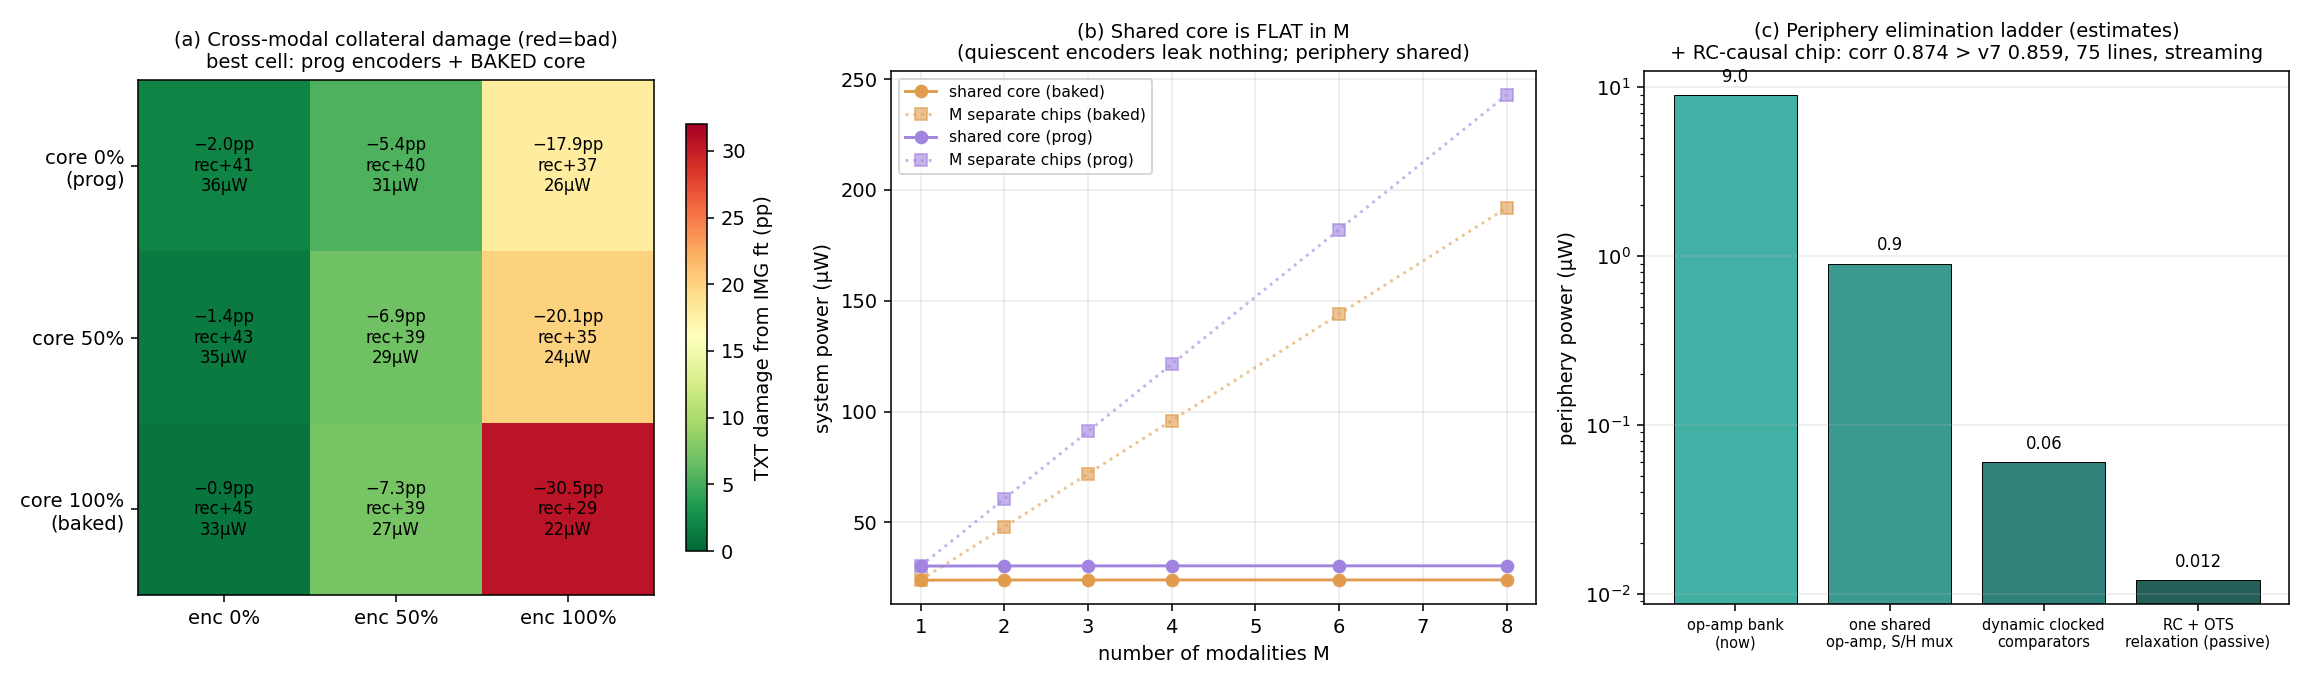

### trimodal_v11.png
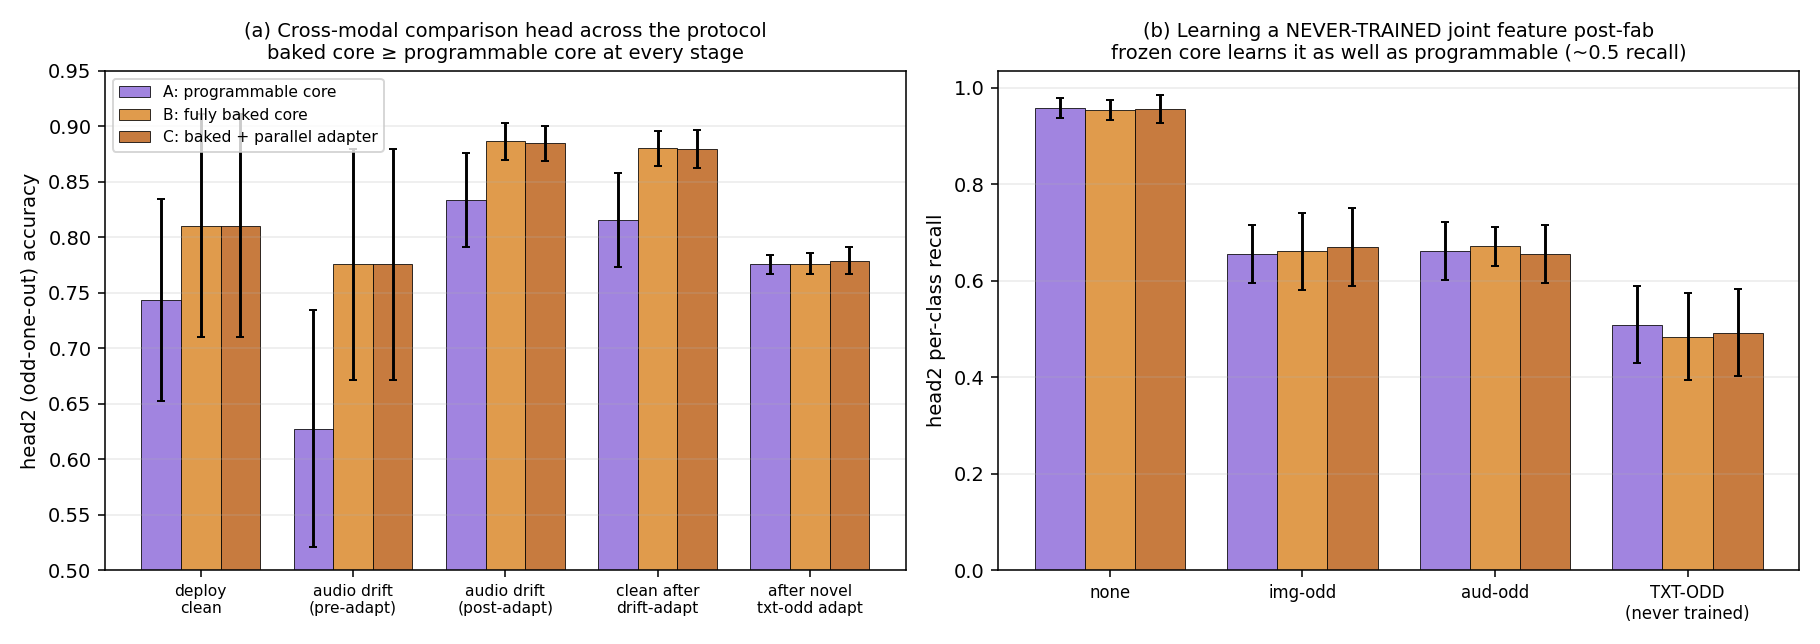

### power_study_v9.png
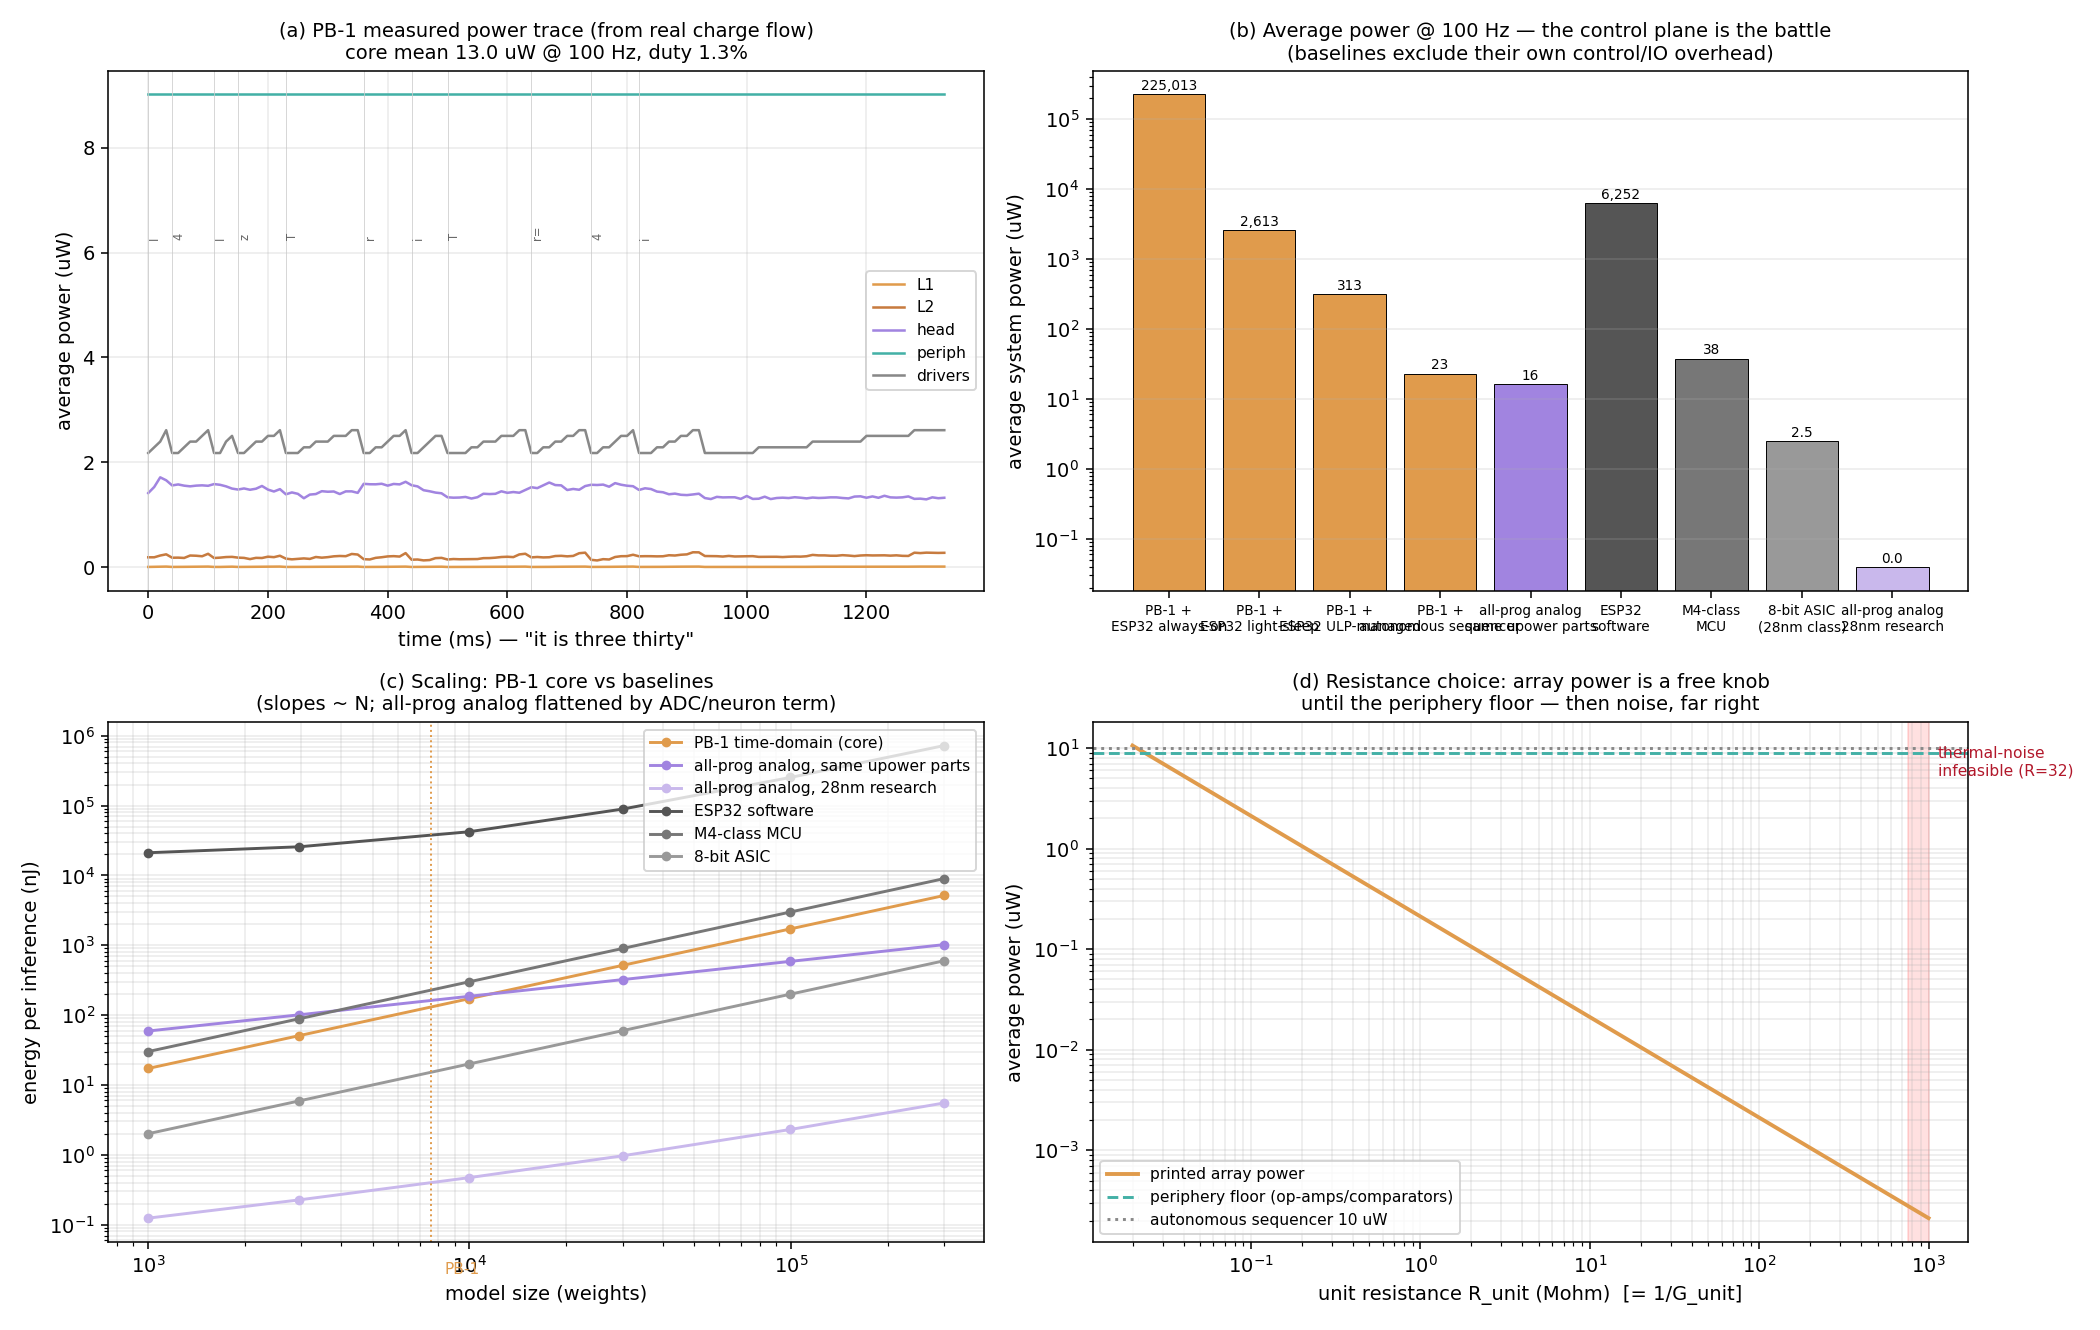

### pb1_hardware.png
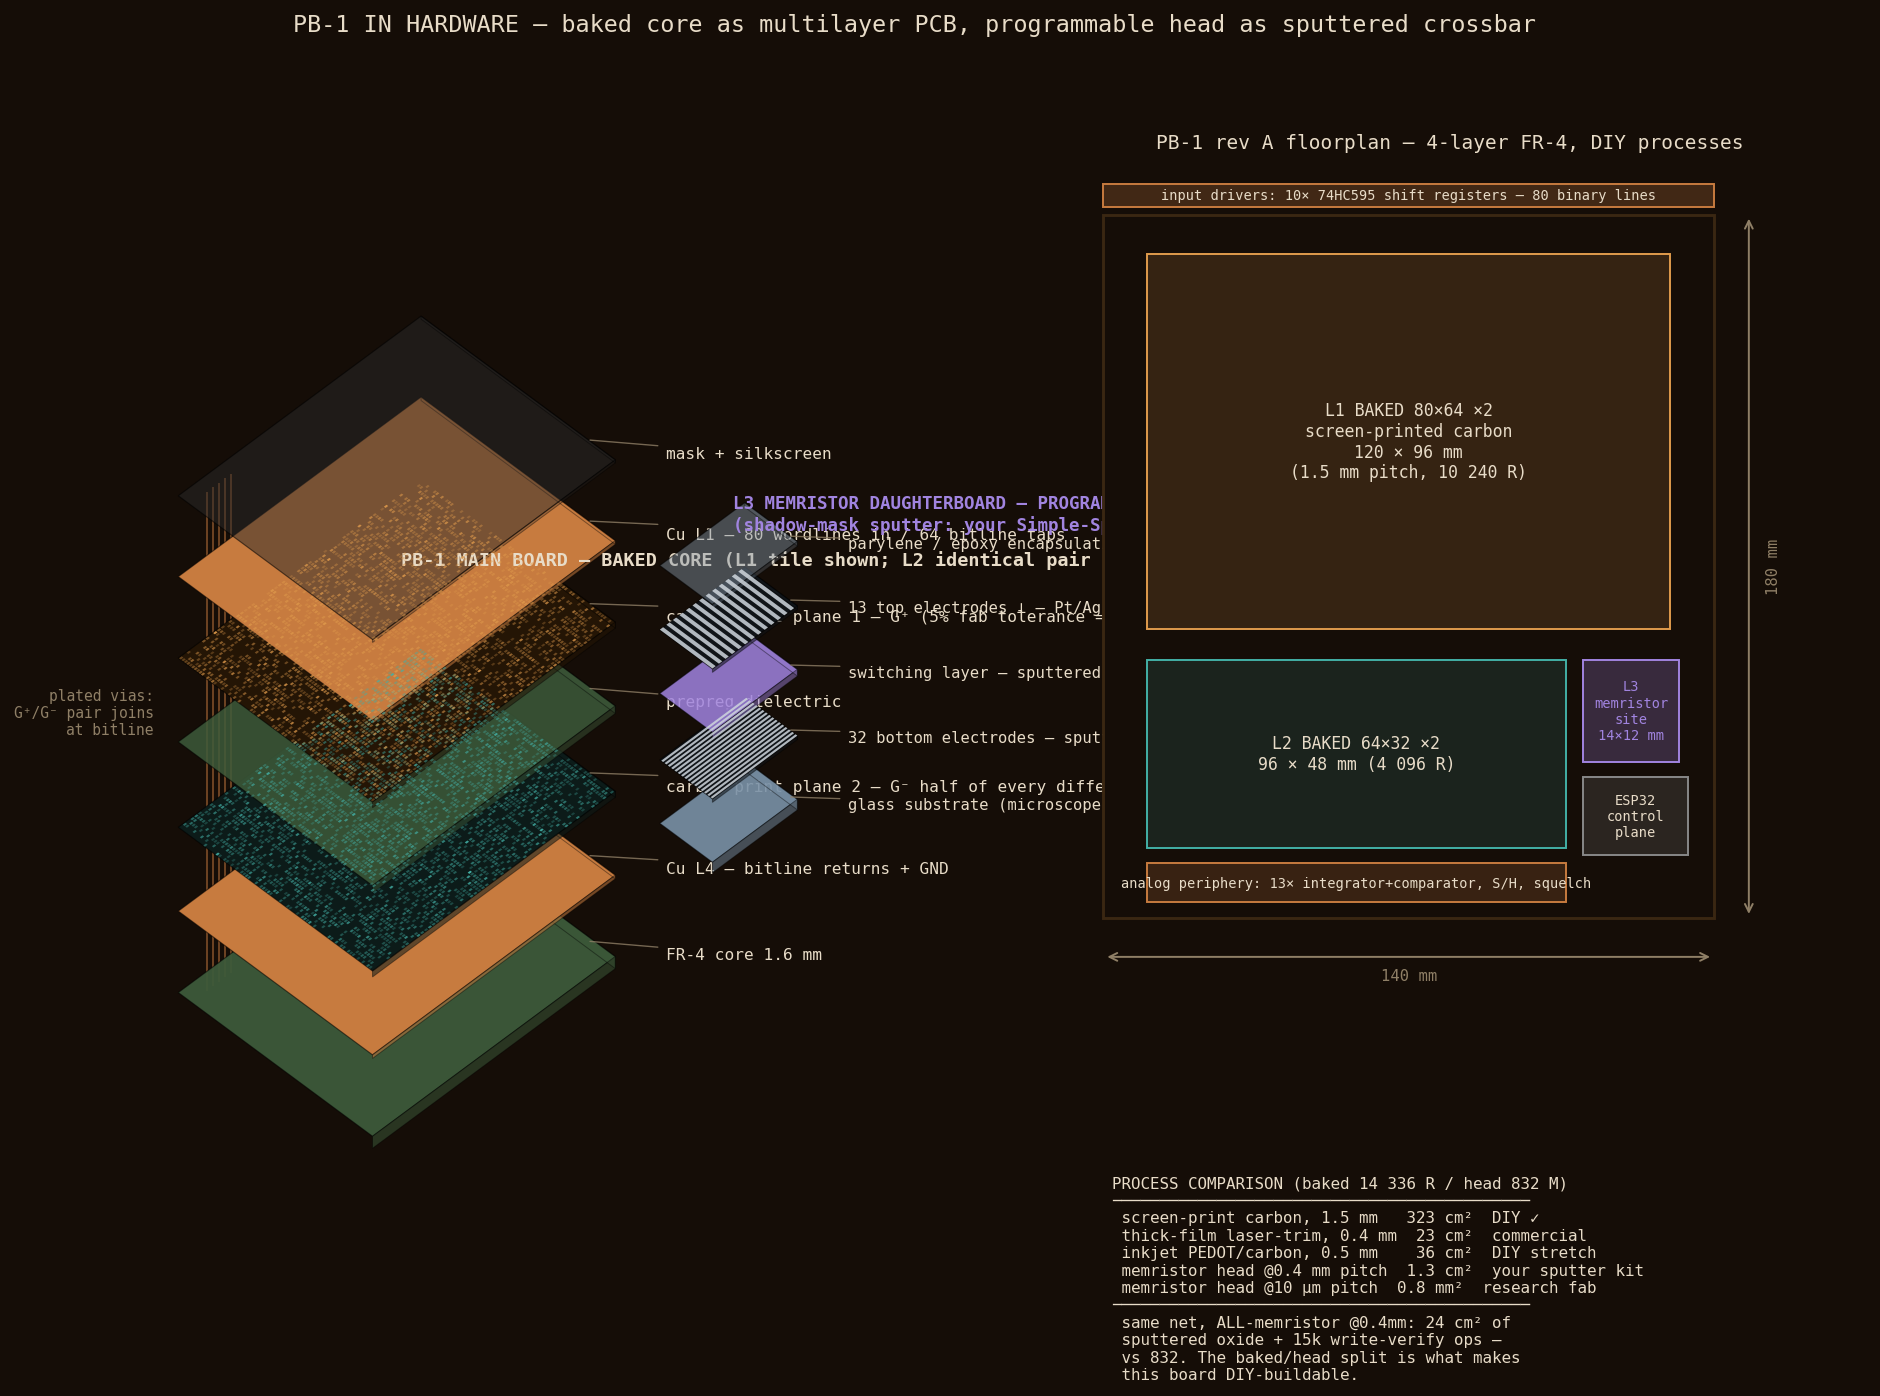

### nodal_ir_v12.png
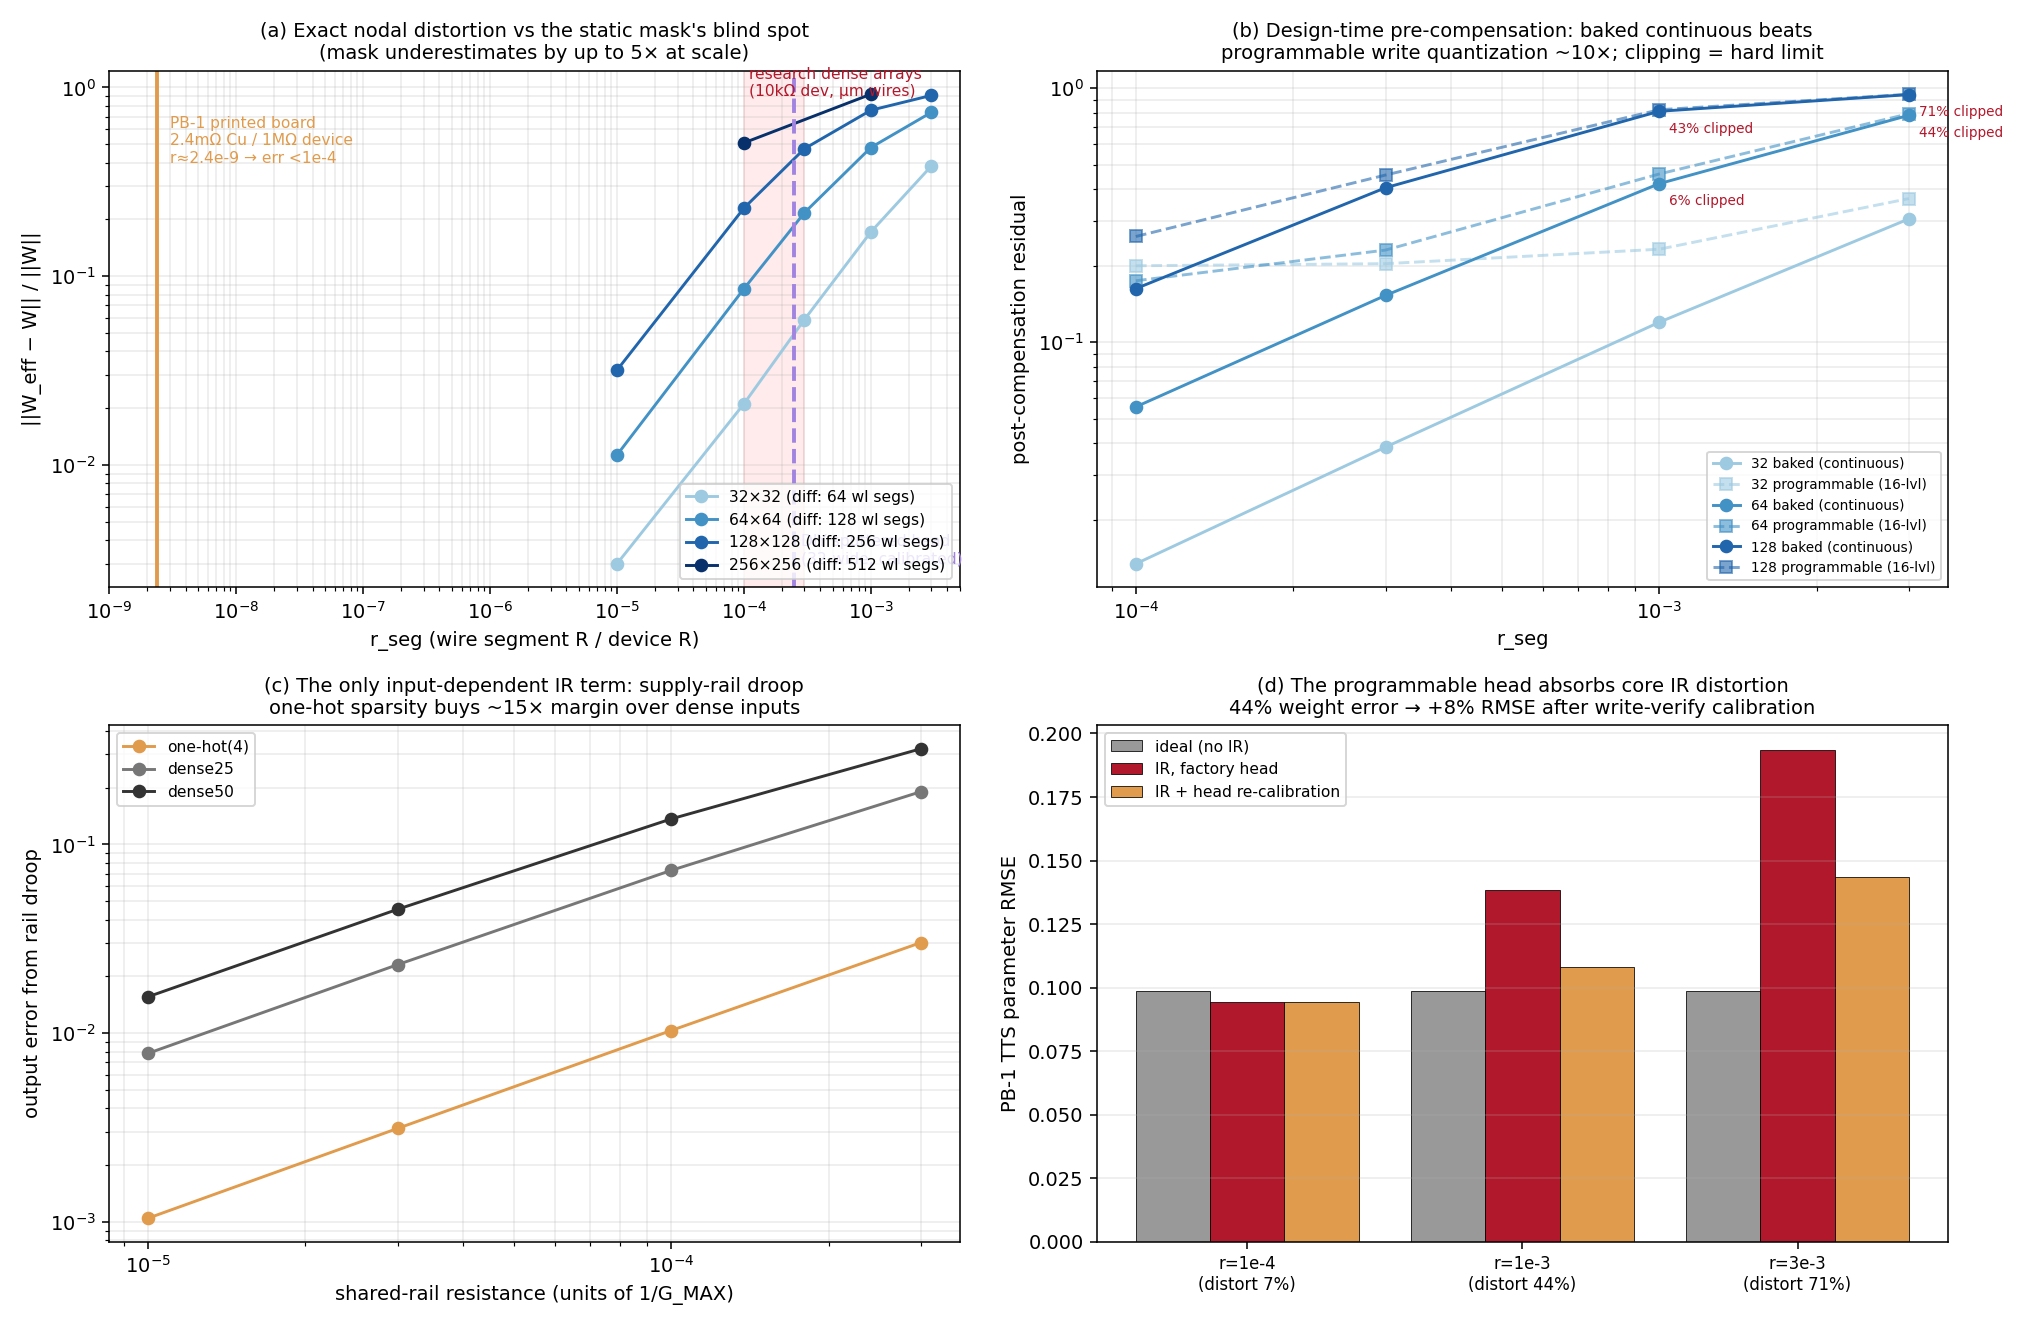